# Testing solver worlds and agreement as FOL checks (Screen Arm B, iter 1)

**What this is.** A demo of *Screen Arm B*: three **gold-free** metrics that try to predict whether a candidate
first-order-logic (FOL) formalization is faithful to its natural-language sentence, compared against baselines.
Everything is measured on **real** Logic-LM FOLIO-dev candidates from three systems (gpt-3.5-turbo, gpt-4,
text-davinci-003). Each candidate is labelled *correct* when z3 proves it equivalent to the FOLIO v1 gold under a
blind predicate bijection (label `L_bij`).

| Metric | What it measures | Cost |
|---|---|---|
| **LC_onecoin** (latent class) | Posterior that a system's candidate is in the correct equivalence class, estimated by a one-coin EM only from *which systems' outputs are solver-equivalent to each other* | z3 + EM, $0 |
| **TVJT** (truth-value judgement) | z3 builds small worlds that separate the candidate from its own typed mutants (negation, quantifier, dropped condition, ...); an LLM judges only the **sentence** in each world; score = agreement with the candidate's truth value | z3 + 1 LLM call |
| **NLI_deberta** (instance consequences) | DeBERTa NLI agreement with the candidate's solver-derived consequences about named individuals | GPU model |
| B1 / B2 / B3sc baselines | LLM judge (0-100 prompt) / parse rate / self-consistency against the same system's other translations | |

**Full-run results (833 candidates, 300 sentences):** LC_onecoin AUROC **0.853** [0.813, 0.888] and the only metric that passes
all pre-registered gates (the rule WINNER). TVJT 0.701 fails G2 (rewrite false alarms), NLI 0.603, B1 judge 0.665.

**What runs live in this notebook vs. from cache.** All the z3 / solver / EM work is re-run live on a 100-sentence subset:
bijection labelling against gold, pairwise cross-system equivalence, self-consistency against alternates, TVJT distinguishing-world
search, the latent-class EM, and the full AUROC / gate analysis. The **LLM and GPU outputs** (the gemini-2.5-flash TVJT answers, the
B1 judge replies, the DeBERTa-large NLI probabilities) are loaded from the original run's cache, so the notebook needs no API key and no GPU.
Live-built TVJT worlds are re-scored against the cached judge answers with the original `score_answers`.

The original script `method.py` is only a stage orchestrator (`build -> b1 -> tvjt -> nli -> lc -> tvjt_nv -> analysis -> export`)
that calls the modules in `src/`. The notebook follows the same stage order and embeds the needed `src/` modules verbatim.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru: NOT pre-installed on Colab -> always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# Core packages: pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports

The import block of `method.py` (argparse is dropped because there is no CLI), plus what the notebook's
analysis and plots need. `src/` is where the original modules are written below so that their own
`import fol_core as fc` style imports keep working unchanged.

In [2]:
from __future__ import annotations

import json
import math
import os
import resource
import sys
import time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold

ROOT = Path.cwd()
(ROOT / "src").mkdir(exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("NLTK_DATA", str(ROOT / "nltk_data"))

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(str(ROOT / "logs" / "run.log"), rotation="30 MB", level="DEBUG")

# memory guard from method.py (soft cap on address space; this demo needs < 1 GB)
_soft, _hard = resource.getrlimit(resource.RLIMIT_AS)
_cap = 60 * 1024**3 if _hard == resource.RLIM_INFINITY else min(60 * 1024**3, _hard)
resource.setrlimit(resource.RLIMIT_AS, (_cap, _hard))

## Load the demo data

`mini_demo_data.json` holds the first 100 of the 300 screen sentences with their real candidates, gold mutants/rewrites, the Logic-LM alternates, and the cached LLM/GPU metric scores.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-abf543-do-sentence-and-formula-generalize-the/main/round-1/experiment-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("fingerprint of the frozen screen set:", data["fingerprint"])
print({k: len(v) for k, v in data["screen_set"].items()}, "| alternates:", len(data["alt_candidates"]),
      "| cached score rows:", len(data["cached_scores"]))

Mini demo subset of Screen Arm B (iter 1): first 100 of the 300 sha1-ordered FOLIO-dev screen sentences, their REAL Logic-LM candidates (gpt-3.5-turbo / gpt-4 / text-davinci-003) with blind z3 bijection labels vs FOLIO v1 gold, gold mutants/rewrites, cached pairwise equivalences and alternates, and cached scores of the API/GPU metrics (B1 judge, TVJT, DeBERTa NLI).
fingerprint of the frozen screen set: a74f4cdd6586fce69e33aa3882e44faeab848d6e
{'sentences': 100, 'real_items': 276, 'mutants': 399, 'rewrites': 171} | alternates: 316 | cached score rows: 5934


## Configuration

All tunable parameters. The original run used 300 sentences (833 candidates) and 1000 bootstrap resamples;
the demo data file holds 100 sentences.

In [5]:
N_SENTENCES = 100   # sentences taken from the demo subset (max 100 here; original full screen: 300)
N_BOOT = 1000        # sentence-clustered bootstrap resamples for AUROC CIs (original: 1000)
EM_RESTARTS = 10      # latent-class EM random restarts (original: 10)
BIJ_WALL_S = 15       # wall-clock cap (s) of one blind-bijection equivalence search between two candidates (original: 15)
ALT_WALL_S = 10       # same cap for candidate-vs-alternate checks used by B3sc (original: 10)
MAX_ALTS = 10         # alternates per candidate for self-consistency (original: 10)
MAX_WORLDS = 12       # max TVJT distinguishing worlds per formula (original: 12)

## Original orchestrator (`method.py`)

For reference, this is the stage loop of `method.py`. Each stage there reads/writes files under `data/` and
`results/`; in the notebook the same stages run cell by cell and keep everything in memory.

```python
stages = ["build", "b1", "tvjt", "nli", "lc", "tvjt_nv", "analysis", "export"] if args.stage == "all" else args.stage.split(",")
for st in stages:
    if st == "build":
        stage_build(args.limit, args.workers)
    else:
        import stages as S
        getattr(S, f"stage_{st}")(args.limit, args.workers)
```

## Module `fol_core.py` — parser, finite-model grounding in z3, blind-bijection equivalence

Written verbatim to `src/`. Key entry points used below:
* `try_parse(fol)` — parses the FOLIO unicode dialect (returns `(ast, error_class)`; unparseable outputs are counted, never dropped);
* `find_bijections(F, G)` — searches arity-preserving predicate/constant bijections (fingerprinted on random finite interpretations) and
  checks each with z3 bounded equivalence; label `equiv` means "equivalent up to renaming", the basis of every label and of the latent-class metric;
* `label_trigram(F, G)` — the secondary, name-anchored (character-trigram Hungarian) map;
* `Grounder` / `py_eval` — finite-domain grounding and a pure-Python evaluator used to double-check TVJT worlds.

In [6]:
%%writefile src/fol_core.py
"""FOL core: tokenizer, parser (FOLIO/Logic-LM unicode syntax), AST utilities, pure-Python finite-model
evaluation, finite-domain grounding into z3 (bounded equivalence / world search), unbounded z3 check,
and blind (arity-preserving bijection) + trigram-anchored equivalence labelling.

AST (hashable tuples, picklable):
  ('atom', name, (t1, ..., tk))        terms are ('v', name) or ('c', name)
  ('eq', t1, t2)
  ('not', A)
  ('and', A1, ..., An) / ('or', A1, ..., An)     n-ary, flattened
  ('imp', A, B) / ('iff', A, B) / ('xor', A, B)
  ('forall', var, A) / ('exists', var, A)
Precedence (as in the GEN_HYPO prototype): ↔ ⊕ (1) < → (2, right-assoc) < ∨ (3) < ∧ (4) < ¬, ∀, ∃.
A quantifier binds a parenthesised group or the next unary formula.
"""
from __future__ import annotations

import itertools
import random
import re
import time
from functools import lru_cache
from typing import Any

import numpy as np
import z3

# ----------------------------------------------------------------------------------------- parsing
_CTR = itertools.count()  # global suffix: fixes the prototype's EnumSort-name-by-hash crash


class ParseError(ValueError):
    def __init__(self, cls: str, msg: str):
        super().__init__(f"{cls}: {msg}")
        self.cls = cls


VAR_NAMES = set("xyzwuvst") | {"x1", "x2", "x3", "y1", "y2", "z1", "z2"}
_REPL = [("<->", "↔"), ("<=>", "↔"), ("->", "→"), ("=>", "→"), ("!=", "≠"), ("&", "∧"), ("|", "∨"),
         ("~", "¬"), ("Ǝ", "∃"), ("⇒", "→"), ("⇔", "↔"), ("≡", "↔"), ("⊻", "⊕"), ("∨", "∨")]
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|≠|=|\(|\)|,|[^\W\d][\w'’]*|\d[\w.]*)")
NON_FOL = set("∈∉⊆⊂≤≥<>{}[]$\"+*/")


def normalize(s: str) -> str:
    s = s.strip()
    for a, b in _REPL:
        s = s.replace(a, b)
    s = re.sub(r"\bforall\s+([a-z])\b", r"∀\1", s)
    s = re.sub(r"\bexists\s+([a-z])\b", r"∃\1", s)
    s = s.rstrip(" .;")
    return s


def tokenize(s: str) -> list[str]:
    out, pos = [], 0
    while pos < len(s):
        if s[pos].isspace():
            pos += 1
            continue
        m = TOK.match(s, pos)
        if not m:
            ch = s[pos]
            raise ParseError("non_FOL" if ch in NON_FOL else "tokenize", f"cannot tokenize at {s[pos:pos+15]!r}")
        out.append(m.group(1))
        pos = m.end()
    return out


BIN = {"↔": ("iff", 1), "⊕": ("xor", 1), "→": ("imp", 2), "∨": ("or", 3), "∧": ("and", 4)}


class _Parser:
    def __init__(self, toks: list[str]):
        self.t, self.i = toks, 0

    def peek(self) -> str | None:
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x: str | None = None) -> str:
        tok = self.peek()
        if tok is None:
            raise ParseError("structure", f"unexpected end, expected {x}")
        if x is not None and tok != x:
            raise ParseError("structure", f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self, minp: int = 1):
        lhs = self.unary()
        while self.peek() in BIN and BIN[self.peek()][1] >= minp:
            op = self.eat()
            kind, p = BIN[op]
            rhs = self.parse(p if op == "→" else p + 1)
            lhs = (kind, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok in ("∀", "∃"):
            self.eat()
            v = self.eat()
            if not re.fullmatch(r"[a-z][a-z0-9]*", v):
                raise ParseError("structure", f"bad quantified variable {v}")
            return ("forall" if tok == "∀" else "exists", v, self.unary())
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok == "(":
            self.eat("(")
            n = self.parse()
            self.eat(")")
            return n
        return self.atom()

    def term(self) -> str:
        tok = self.eat()
        if not re.fullmatch(r"[\w.'’]+", tok):
            raise ParseError("structure", f"bad term {tok}")
        if self.peek() == "(":
            raise ParseError("function_term", f"function term {tok}(...)")
        return tok

    def atom(self):
        tok = self.peek()
        if tok is None or not re.fullmatch(r"[\w.'’]+", tok):
            raise ParseError("structure", f"expected atom got {tok}")
        name = self.eat()
        if self.peek() == "(":
            self.eat("(")
            args = []
            if self.peek() == ")":
                self.eat(")")
                return ("atomraw", name, ())
            while True:
                args.append(self.term())
                if self.peek() == ",":
                    self.eat(",")
                    continue
                self.eat(")")
                break
            node = ("atomraw", name, tuple(args))
        else:
            node = ("termraw", name)
        if self.peek() in ("=", "≠"):
            op = self.eat()
            rhs = self.term()
            if node[0] != "termraw":
                raise ParseError("non_FOL", "function term in equality")
            eq = ("eqraw", node[1], rhs)
            return ("not", eq) if op == "≠" else eq
        if node[0] == "termraw":
            return ("atomraw", name, ())  # propositional atom
        return node


def _resolve(n, bound: frozenset):
    k = n[0]
    if k == "atomraw":
        return ("atom", n[1], tuple(("v", a) if a in bound else ("c", a) for a in n[2]))
    if k == "eqraw":
        return ("eq", ("v", n[1]) if n[1] in bound else ("c", n[1]), ("v", n[2]) if n[2] in bound else ("c", n[2]))
    if k in ("forall", "exists"):
        return (k, n[1], _resolve(n[2], bound | {n[1]}))
    if k == "not":
        return ("not", _resolve(n[1], bound))
    return (k,) + tuple(_resolve(a, bound) for a in n[1:])


def flatten(n):
    k = n[0]
    if k in ("and", "or"):
        out = []
        for a in n[1:]:
            a = flatten(a)
            if a[0] == k:
                out.extend(a[1:])
            else:
                out.append(a)
        return (k,) + tuple(out)
    if k in ("atom", "eq"):
        return n
    if k in ("forall", "exists"):
        return (k, n[1], flatten(n[2]))
    return (k,) + tuple(flatten(a) for a in n[1:])


@lru_cache(maxsize=200000)
def parse(fol: str):
    s = normalize(fol)
    if not s:
        raise ParseError("structure", "empty")
    toks = tokenize(s)
    p = _Parser(toks)
    raw = p.parse()
    if p.i != len(toks):
        raise ParseError("structure", f"trailing tokens {toks[p.i:p.i+5]}")
    ast = flatten(_resolve(raw, frozenset()))
    fv = [c for c in constants(ast) if c in VAR_NAMES]
    if fv:
        raise ParseError("free_var", f"free variables {fv}")
    sig = predicates(ast, strict=False)
    if sig is None:
        raise ParseError("structure", "predicate used with inconsistent arity")
    return ast


def try_parse(fol: str):
    try:
        return parse(fol), None
    except ParseError as e:
        return None, e.cls
    except RecursionError:
        return None, "structure"


# ----------------------------------------------------------------------------------------- AST utils
def predicates(n, strict: bool = True) -> dict[str, int] | None:
    acc: dict[str, int] = {}
    ok = [True]

    def rec(m):
        if m[0] == "atom":
            if m[1] in acc and acc[m[1]] != len(m[2]):
                ok[0] = False
            acc[m[1]] = len(m[2])
        elif m[0] == "eq":
            return
        elif m[0] in ("forall", "exists"):
            rec(m[2])
        else:
            for a in m[1:]:
                rec(a)
    rec(n)
    if not ok[0]:
        if strict:
            raise ParseError("structure", "inconsistent arity")
        return None
    return acc


def constants(n) -> list[str]:
    acc: list[str] = []

    def rec(m):
        if m[0] == "atom":
            for t in m[2]:
                if t[0] == "c" and t[1] not in acc:
                    acc.append(t[1])
        elif m[0] == "eq":
            for t in m[1:]:
                if t[0] == "c" and t[1] not in acc:
                    acc.append(t[1])
        elif m[0] in ("forall", "exists"):
            rec(m[2])
        else:
            for a in m[1:]:
                rec(a)
    rec(n)
    return acc


def depth(n) -> int:
    if n[0] in ("atom", "eq"):
        return 1
    if n[0] in ("forall", "exists"):
        return 1 + depth(n[2])
    return 1 + max(depth(a) for a in n[1:])


def count_ops(n, kinds: set[str]) -> int:
    c = 1 if n[0] in kinds else 0
    if n[0] in ("atom", "eq"):
        return c
    if n[0] in ("forall", "exists"):
        return c + count_ops(n[2], kinds)
    return c + sum(count_ops(a, kinds) for a in n[1:])


def has_equality(n) -> bool:
    return count_ops(n, {"eq"}) > 0


def to_str(n) -> str:
    k = n[0]
    if k == "atom":
        return f"{n[1]}({', '.join(t[1] for t in n[2])})" if n[2] else n[1]
    if k == "eq":
        return f"{n[1][1]} = {n[2][1]}"
    if k == "not":
        a = n[1]
        if a[0] == "eq":
            return f"{a[1][1]} ≠ {a[2][1]}"
        return "¬" + (to_str(a) if a[0] in ("atom", "not", "forall", "exists") else f"({to_str(a)})")
    if k in ("forall", "exists"):
        body = n[2]
        q = "∀" if k == "forall" else "∃"
        if body[0] in ("forall", "exists"):
            return f"{q}{n[1]} {to_str(body)}"
        return f"{q}{n[1]} ({to_str(body)})"
    sym = {"and": " ∧ ", "or": " ∨ ", "imp": " → ", "iff": " ↔ ", "xor": " ⊕ "}[k]

    def wrap(a):
        return to_str(a) if a[0] in ("atom", "eq", "not", "forall", "exists") else f"({to_str(a)})"
    return sym.join(wrap(a) for a in n[1:])


def rename(n, pmap: dict[str, str], cmap: dict[str, str]):
    k = n[0]
    if k == "atom":
        return ("atom", pmap.get(n[1], n[1]), tuple(("c", cmap.get(t[1], t[1])) if t[0] == "c" else t for t in n[2]))
    if k == "eq":
        return ("eq",) + tuple(("c", cmap.get(t[1], t[1])) if t[0] == "c" else t for t in n[1:])
    if k in ("forall", "exists"):
        return (k, n[1], rename(n[2], pmap, cmap))
    return (k,) + tuple(rename(a, pmap, cmap) for a in n[1:])


# ------------------------------------------------------------------------------ pure-python evaluation
def py_eval(n, interp: dict, dom: int, env: dict | None = None) -> bool:
    """interp: {'P': {pred: set(tuples)}, 'C': {const: int}}; domain = range(dom)."""
    env = env or {}
    k = n[0]
    if k == "atom":
        tup = tuple(env[t[1]] if t[0] == "v" else interp["C"][t[1]] for t in n[2])
        return tup in interp["P"].get(n[1], ())
    if k == "eq":
        a, b = (env[t[1]] if t[0] == "v" else interp["C"][t[1]] for t in n[1:])
        return a == b
    if k == "not":
        return not py_eval(n[1], interp, dom, env)
    if k == "and":
        return all(py_eval(a, interp, dom, env) for a in n[1:])
    if k == "or":
        return any(py_eval(a, interp, dom, env) for a in n[1:])
    if k == "imp":
        return (not py_eval(n[1], interp, dom, env)) or py_eval(n[2], interp, dom, env)
    if k == "iff":
        return py_eval(n[1], interp, dom, env) == py_eval(n[2], interp, dom, env)
    if k == "xor":
        return py_eval(n[1], interp, dom, env) != py_eval(n[2], interp, dom, env)
    if k == "forall":
        return all(py_eval(n[2], interp, dom, {**env, n[1]: d}) for d in range(dom))
    if k == "exists":
        return any(py_eval(n[2], interp, dom, {**env, n[1]: d}) for d in range(dom))
    raise ValueError(k)


def random_interps(preds: dict[str, int], consts: list[str], n_interp: int, seed: int, sizes=(2, 3)) -> list:
    rng = random.Random(seed)
    out = []
    for i in range(n_interp):
        dom = sizes[i % len(sizes)]
        P = {}
        for p, k in preds.items():
            P[p] = {t for t in itertools.product(range(dom), repeat=k) if rng.random() < 0.5}
        C = {c: rng.randrange(dom) for c in consts}
        out.append(({"P": P, "C": C}, dom))
    return out


# ------------------------------------------------------------------------------ finite grounding (z3)
class Grounder:
    """Ground formulas over domain {0..n-1}. Predicate atoms -> z3 Bools shared by name+tuple.
    Constants: fixed ints (una=True: distinct elements 0..k-1) or z3 Int vars in [0,n) (no UNA)."""

    def __init__(self, n: int, consts: list[str], una: bool, tag: str = ""):
        self.n = n
        self.tag = tag or f"g{next(_CTR)}"
        self.atoms: dict[tuple, z3.BoolRef] = {}
        self.side: list = []
        if una:
            if len(consts) > n:
                raise ValueError("too many constants for UNA domain")
            self.C: dict[str, Any] = {c: i for i, c in enumerate(consts)}
        else:
            self.C = {}
            for c in consts:
                v = z3.Int(f"{self.tag}_c_{c}")
                self.C[c] = v
                self.side.append(z3.And(v >= 0, v < n))

    def const(self, c: str):
        if c not in self.C:  # constant not declared up-front (no-UNA mode only)
            v = z3.Int(f"{self.tag}_c_{c}")
            self.C[c] = v
            self.side.append(z3.And(v >= 0, v < self.n))
        return self.C[c]

    def atom(self, p: str, tup: tuple[int, ...]) -> z3.BoolRef:
        key = (p, tup)
        if key not in self.atoms:
            self.atoms[key] = z3.Bool(f"{self.tag}|{p}|{','.join(map(str, tup))}")
        return self.atoms[key]

    def g(self, f, env: dict | None = None):
        env = env or {}
        k = f[0]
        if k == "atom":
            vals = [env[t[1]] if t[0] == "v" else self.const(t[1]) for t in f[2]]
            if all(isinstance(v, int) for v in vals):
                return self.atom(f[1], tuple(vals))
            choices = [[(v, None)] if isinstance(v, int) else [(d, v == d) for d in range(self.n)] for v in vals]
            disj = []
            for combo in itertools.product(*choices):
                conds = [c for _, c in combo if c is not None]
                disj.append(z3.And(*conds, self.atom(f[1], tuple(d for d, _ in combo))))
            return z3.Or(*disj)
        if k == "eq":
            a, b = (env[t[1]] if t[0] == "v" else self.const(t[1]) for t in f[1:])
            if isinstance(a, int) and isinstance(b, int):
                return z3.BoolVal(a == b)
            return a == b
        if k == "not":
            return z3.Not(self.g(f[1], env))
        if k == "and":
            return z3.And(*[self.g(a, env) for a in f[1:]])
        if k == "or":
            return z3.Or(*[self.g(a, env) for a in f[1:]])
        if k == "imp":
            return z3.Implies(self.g(f[1], env), self.g(f[2], env))
        if k == "iff":
            return self.g(f[1], env) == self.g(f[2], env)
        if k == "xor":
            return z3.Xor(self.g(f[1], env), self.g(f[2], env))
        if k == "forall":
            return z3.And(*[self.g(f[2], {**env, f[1]: d}) for d in range(self.n)])
        if k == "exists":
            return z3.Or(*[self.g(f[2], {**env, f[1]: d}) for d in range(self.n)])
        raise ValueError(k)


def _check(constraints: list, timeout_ms: int) -> z3.CheckSatResult:
    s = z3.Solver()
    s.set("timeout", timeout_ms)
    s.add(*constraints)
    return s.check()


def satisfiable(f, nmax: int = 4, timeout_ms: int = 5000) -> str:
    """'sat' if F has a model with domain size <= nmax, 'unsat' if none, 'unknown' on timeout."""
    cs = constants(f)
    unk = False
    for n in range(1, nmax + 1):
        g = Grounder(n, cs, una=False)
        r = _check([g.g(f)] + g.side, timeout_ms)
        if r == z3.sat:
            return "sat"
        if r == z3.unknown:
            unk = True
    return "unknown" if unk else "unsat"


def bounded_equiv(f, g, nmax: int = 4, timeout_ms: int = 5000) -> str:
    """'equiv' | 'nonequiv' | 'unknown' over all domains of size 1..nmax (constants may co-refer)."""
    cs = list(dict.fromkeys(constants(f) + constants(g)))
    unk = False
    for n in range(1, nmax + 1):
        gr = Grounder(n, cs, una=False)
        r = _check([z3.Xor(gr.g(f), gr.g(g))] + gr.side, timeout_ms)
        if r == z3.sat:
            return "nonequiv"
        if r == z3.unknown:
            unk = True
    return "unknown" if unk else "equiv"


def equiv_under_map(F, G, pmap: dict, cmap: dict, nmax: int = 4, timeout_ms: int = 5000) -> str:
    return bounded_equiv(rename(F, pmap, cmap), G, nmax=nmax, timeout_ms=timeout_ms)


def unbounded_equiv(F, G, timeout_ms: int = 5000) -> str:
    """Uninterpreted-sort check sat(F xor G): unsat -> equiv (valid), sat -> nonequiv, else unknown."""
    D = z3.DeclareSort(f"U{next(_CTR)}")
    preds = {**predicates(F), **predicates(G)}
    P = {p: (z3.Function(f"{p}_{next(_CTR)}", *([D] * k), z3.BoolSort()) if k else z3.Bool(f"{p}_{next(_CTR)}"))
         for p, k in preds.items()}
    C = {c: z3.Const(f"c_{c}_{next(_CTR)}", D) for c in set(constants(F)) | set(constants(G))}

    def tz(f, env):
        k = f[0]
        if k == "atom":
            fn = P[f[1]]
            if not f[2]:
                return fn
            return fn(*[env[t[1]] if t[0] == "v" else C[t[1]] for t in f[2]])
        if k == "eq":
            a, b = (env[t[1]] if t[0] == "v" else C[t[1]] for t in f[1:])
            return a == b
        if k in ("forall", "exists"):
            v = z3.Const(f"v_{f[1]}_{next(_CTR)}", D)
            body = tz(f[2], {**env, f[1]: v})
            return z3.ForAll([v], body) if k == "forall" else z3.Exists([v], body)
        a = [tz(x, env) for x in f[1:]]
        if k == "not":
            return z3.Not(a[0])
        if k == "and":
            return z3.And(*a)
        if k == "or":
            return z3.Or(*a)
        if k == "imp":
            return z3.Implies(a[0], a[1])
        if k == "iff":
            return a[0] == a[1]
        if k == "xor":
            return z3.Xor(a[0], a[1])
        raise ValueError(k)
    r = _check([z3.Xor(tz(F, {}), tz(G, {}))], timeout_ms)
    if r == z3.unsat:
        return "equiv"
    if r == z3.sat:
        return "nonequiv"
    return "unknown"


# ------------------------------------------------------------------------------ bijection labelling
def _arity_classes(preds: dict[str, int]) -> dict[int, list[str]]:
    out: dict[int, list[str]] = {}
    for p, k in sorted(preds.items()):
        out.setdefault(k, []).append(p)
    return out


def _truth_vector(f, interps) -> tuple:
    return tuple(py_eval(f, it, d) for it, d in interps)


def find_bijections(F, G, cap: int = 5040, n_fp: int = 64, max_preds: int = 8, wall_s: float = 30.0,
                    max_equiv: int = 5, nmax: int = 4, timeout_ms: int = 5000) -> dict:
    """Blind label: is there an arity-preserving bijection of predicates (and a bijection of constants)
    under which candidate F is bounded-equivalent (domains 1..nmax) to gold G?"""
    t0 = time.time()
    pF, pG = predicates(F), predicates(G)
    cF, cG = constants(F), constants(G)
    aF, aG = _arity_classes(pF), _arity_classes(pG)
    if sorted(pF.values()) != sorted(pG.values()) or len(cF) != len(cG):
        return {"label": "nonequiv", "reason": "vocab_mismatch", "map": None, "n_equiv_maps": 0, "n_maps": 0}
    if len(pF) > max_preds:
        return {"label": "unlabeled", "reason": "too_many_preds", "map": None, "n_equiv_maps": 0, "n_maps": 0}
    per_class = [list(itertools.permutations(aG[k])) for k in sorted(aF)]
    n_maps = 1
    for pc in per_class:
        n_maps *= len(pc)
    n_cmaps = 1
    for i in range(2, len(cG) + 1):
        n_cmaps *= i
    total = n_maps * n_cmaps
    if total > cap:
        return {"label": "unlabeled", "reason": "too_many_maps", "map": None, "n_equiv_maps": 0, "n_maps": total}
    interps = random_interps(pG, cG, n_fp, seed=12345)
    vG = _truth_vector(G, interps)
    keysF = [aF[k] for k in sorted(aF)]
    survivors = []
    for combo in itertools.product(*per_class):
        pmap = {}
        for srcs, tgts in zip(keysF, combo):
            pmap.update(dict(zip(srcs, tgts)))
        for cperm in itertools.permutations(cG):
            cmap = dict(zip(cF, cperm))
            RF = rename(F, pmap, cmap)
            if _truth_vector(RF, interps) == vG:
                survivors.append((pmap, cmap))
        if time.time() - t0 > wall_s:
            return {"label": "unlabeled", "reason": "timeout", "map": None, "n_equiv_maps": 0, "n_maps": total}
    first, n_eq, unk = None, 0, False
    for pmap, cmap in survivors:
        r = equiv_under_map(F, G, pmap, cmap, nmax=nmax, timeout_ms=timeout_ms)
        if r == "equiv":
            n_eq += 1
            if first is None:
                first = (pmap, cmap)
            if n_eq >= max_equiv:
                break
        elif r == "unknown":
            unk = True
        if time.time() - t0 > wall_s:
            break
    if first is not None:
        return {"label": "equiv", "reason": "bijection", "map": {"P": first[0], "C": first[1]},
                "n_equiv_maps": n_eq, "n_maps": total, "n_survivors": len(survivors)}
    if unk or time.time() - t0 > wall_s:
        return {"label": "unlabeled", "reason": "solver_unknown", "map": None, "n_equiv_maps": 0, "n_maps": total}
    return {"label": "nonequiv", "reason": "no_equiv_map", "map": None, "n_equiv_maps": 0, "n_maps": total,
            "n_survivors": len(survivors)}


def _trigrams(s: str) -> set[str]:
    s = f"  {s.lower()} "
    return {s[i:i + 3] for i in range(len(s) - 2)}


def _hungarian(src: list[str], tgt: list[str]) -> dict[str, str]:
    from scipy.optimize import linear_sum_assignment
    if not src:
        return {}
    cost = np.zeros((len(src), len(tgt)))
    for i, a in enumerate(src):
        ta = _trigrams(a)
        for j, b in enumerate(tgt):
            tb = _trigrams(b)
            cost[i, j] = 1 - len(ta & tb) / max(1, len(ta | tb))
    r, c = linear_sum_assignment(cost)
    return {src[i]: tgt[j] for i, j in zip(r, c)}


def trigram_map(F, G) -> tuple[dict, dict] | None:
    pF, pG = predicates(F), predicates(G)
    cF, cG = constants(F), constants(G)
    if sorted(pF.values()) != sorted(pG.values()) or len(cF) != len(cG):
        return None
    aF, aG = _arity_classes(pF), _arity_classes(pG)
    pmap = {}
    for k in aF:
        pmap.update(_hungarian(aF[k], aG[k]))
    return pmap, _hungarian(cF, cG)


def label_trigram(F, G, nmax: int = 4, timeout_ms: int = 5000) -> dict:
    m = trigram_map(F, G)
    if m is None:
        return {"label": "nonequiv", "reason": "vocab_mismatch", "map": None}
    r = equiv_under_map(F, G, m[0], m[1], nmax=nmax, timeout_ms=timeout_ms)
    return {"label": {"equiv": "equiv", "nonequiv": "nonequiv"}.get(r, "unlabeled"), "reason": "trigram",
            "map": {"P": m[0], "C": m[1]}}

Writing src/fol_core.py


## Module `mutants.py` — typed error operators

Deterministic (sha1-seeded) typed mutations of a formula: `NEG`, `QUANT`, `IMPL_REV`, `DROP_CONJ`, `ADD_CONJ`, `ARG_SWAP`,
`AND_OR`, `SCOPE_SWAP`, `MERGE`, `CARD`, plus meaning-preserving rewrites. A mutant is kept only if z3 shows it is **not**
equivalent to its source. TVJT builds its worlds against the candidate's own mutants.

In [7]:
%%writefile src/mutants.py
"""Typed mutation operators (known error types) and meaning-preserving rewrites over fol_core ASTs.

Every operator enumerates its applicable sites in pre-order; sites are tried in a seeded order
(rng = Random(sha1(seed_key + op))) and the first site whose mutant is NOT bounded-equivalent (n<=4)
to the source under the identity map is kept. Rewrites are kept only if bounded-equivalent.
"""
from __future__ import annotations

import os as _os
from pathlib import Path as _Path

_os.environ.setdefault("NLTK_DATA", str(_Path(__file__).resolve().parents[1] / "nltk_data"))

import hashlib
import random
import re
from typing import Callable, Iterator

from fol_core import bounded_equiv, constants, predicates, rename, to_str

OPERATORS = ["NEG", "QUANT", "IMPL_REV", "DROP_CONJ", "ADD_CONJ", "ARG_SWAP", "AND_OR", "SCOPE_SWAP", "MERGE", "CARD"]
OP_FAMILY = {"NEG": "negation/polarity", "QUANT": "quantifier", "SCOPE_SWAP": "quantifier-scope",
             "CARD": "quantifier-cardinality", "IMPL_REV": "implication-direction", "DROP_CONJ": "dropped-condition",
             "ADD_CONJ": "added-condition", "ARG_SWAP": "swapped-arguments", "AND_OR": "connective",
             "MERGE": "conflated-concepts"}
REWRITES = ["RENAME", "REORDER", "CONTRAPOSITIVE", "DEMORGAN", "PRENEX"]


def rng_for(key: str, op: str) -> random.Random:
    return random.Random(int(hashlib.sha1(f"{key}|{op}".encode()).hexdigest()[:12], 16))


# ----------------------------------------------------------------------------------------- tree nav
def children(n) -> list:
    if n[0] in ("atom", "eq"):
        return []
    if n[0] in ("forall", "exists"):
        return [n[2]]
    return list(n[1:])


def preorder(n, path=()) -> Iterator[tuple[tuple, tuple]]:
    yield path, n
    for i, c in enumerate(children(n)):
        yield from preorder(c, path + (i,))


def get(n, path):
    for i in path:
        n = children(n)[i]
    return n


def replace(n, path, new):
    if not path:
        return new
    i = path[0]
    if n[0] in ("forall", "exists"):
        return (n[0], n[1], replace(n[2], path[1:], new))
    kids = list(n[1:])
    kids[i] = replace(kids[i], path[1:], new)
    return (n[0],) + tuple(kids)


def neg(x):
    return x[1] if x[0] == "not" else ("not", x)


def mk_and(parts):
    parts = [p for q in parts for p in (q[1:] if q[0] == "and" else (q,))]
    return parts[0] if len(parts) == 1 else ("and",) + tuple(parts)


def all_vars(n) -> set[str]:
    out = set()
    for _, m in preorder(n):
        if m[0] in ("forall", "exists"):
            out.add(m[1])
        elif m[0] == "atom":
            out.update(t[1] for t in m[2] if t[0] == "v")
        elif m[0] == "eq":
            out.update(t[1] for t in m[1:] if t[0] == "v")
    return out


def fresh_var(used: set[str]) -> str:
    for v in ["y", "z", "w", "u", "v", "t", "s"] + [f"x{i}" for i in range(1, 50)]:
        if v not in used:
            return v
    raise ValueError("no fresh var")


def subst_var(n, old: str, new: str):
    """Replace free occurrences of variable old by variable new."""
    k = n[0]
    if k == "atom":
        return ("atom", n[1], tuple(("v", new) if t == ("v", old) else t for t in n[2]))
    if k == "eq":
        return ("eq",) + tuple(("v", new) if t == ("v", old) else t for t in n[1:])
    if k in ("forall", "exists"):
        if n[1] == old:
            return n
        return (k, n[1], subst_var(n[2], old, new))
    return (k,) + tuple(subst_var(a, old, new) for a in n[1:])


def free_vars(n, bound=frozenset()) -> set[str]:
    k = n[0]
    if k == "atom":
        return {t[1] for t in n[2] if t[0] == "v" and t[1] not in bound}
    if k == "eq":
        return {t[1] for t in n[1:] if t[0] == "v" and t[1] not in bound}
    if k in ("forall", "exists"):
        return free_vars(n[2], bound | {n[1]})
    out = set()
    for a in n[1:]:
        out |= free_vars(a, bound)
    return out


def has_quant(n) -> bool:
    return any(m[0] in ("forall", "exists") for _, m in preorder(n))


# ----------------------------------------------------------------------------------------- prenex
class NotPrenexable(Exception):
    pass


def pnf(n, used: set[str]) -> tuple[list, tuple]:
    k = n[0]
    if k in ("atom", "eq"):
        return [], n
    if k == "not":
        p, m = pnf(n[1], used)
        return [("exists" if q == "forall" else "forall", v) for q, v in p], neg(m)
    if k in ("forall", "exists"):
        v, body = n[1], n[2]
        if v in used:
            nv = fresh_var(used | all_vars(n))
            body = subst_var(body, v, nv)
            v = nv
        used.add(v)
        p, m = pnf(body, used)
        return [(k, v)] + p, m
    if k in ("and", "or"):
        pre, mats = [], []
        for a in n[1:]:
            p, m = pnf(a, used)
            pre += p
            mats.append(m)
        return pre, (k,) + tuple(mats)
    if k == "imp":
        p1, m1 = pnf(("not", n[1]), used)
        p2, m2 = pnf(n[2], used)
        return p1 + p2, ("imp", neg(m1) if True else m1, m2)
    if k in ("iff", "xor"):
        if has_quant(n):
            raise NotPrenexable(k)
        return [], n
    raise ValueError(k)


def build_prefix(prefix, matrix):
    out = matrix
    for q, v in reversed(prefix):
        out = (q, v, out)
    return out


def prenex(n):
    p, m = pnf(n, set())
    return p, m


# ----------------------------------------------------------------------------------------- operators
def _op_neg(F, rng):
    sites = []
    for path, m in preorder(F):
        if m[0] == "atom":
            if path and get(F, path[:-1])[0] == "not":
                sites.append(replace(F, path[:-1], m))
            else:
                sites.append(replace(F, path, ("not", m)))
    return sites


def _op_quant(F, rng):
    sites = []
    for path, m in preorder(F):
        if m[0] == "forall":
            b = m[2]
            nb = mk_and([b[1], b[2]]) if b[0] == "imp" else b
            sites.append(replace(F, path, ("exists", m[1], nb)))
        elif m[0] == "exists":
            b = m[2]
            if b[0] == "and":
                rest = b[2] if len(b) == 3 else ("and",) + b[2:]
                nb = ("imp", b[1], rest)
            else:
                nb = b
            sites.append(replace(F, path, ("forall", m[1], nb)))
    return sites


def _op_impl_rev(F, rng):
    return [replace(F, p, ("imp", m[2], m[1])) for p, m in preorder(F) if m[0] == "imp"]


def _restrictor_paths(F) -> list[tuple]:
    """Paths of restrictor positions: antecedents of → and the first conjunct under ∃."""
    out = []
    for p, m in preorder(F):
        if m[0] == "imp":
            out.append(p + (0,))
        elif m[0] == "exists" and m[2][0] == "and":
            out.append(p + (0, 0))
    return out


def _op_drop_conj(F, rng):
    restr = set()
    for rp in _restrictor_paths(F):
        restr.add(rp)
    ands = [(p, m) for p, m in preorder(F) if m[0] == "and"]
    # restrictor-side and-nodes first (the antecedent itself is an ∧, or ∃-body ∧)
    ands.sort(key=lambda pm: 0 if (pm[0] in restr or any(pm[0][:len(r)] == r for r in restr)) else 1)
    sites = []
    for p, m in ands:
        idx = list(range(len(m) - 1))
        rng.shuffle(idx)
        for i in idx:
            rest = [c for j, c in enumerate(m[1:]) if j != i]
            sites.append(replace(F, p, rest[0] if len(rest) == 1 else ("and",) + tuple(rest)))
    return sites


def _op_add_conj(F, rng):
    sites = []
    preds = predicates(F)
    name = "NewCond"
    while name in preds:
        name += "X"
    for p, m in preorder(F):
        if m[0] in ("forall", "exists"):
            v, b = m[1], m[2]
            if b[0] == "imp" and v in free_vars(b[1]):
                sites.append(replace(F, p + (0, 0), mk_and([b[1], ("atom", name, (("v", v),))])))
            elif m[0] == "exists":
                sites.append(replace(F, p + (0,), mk_and([b, ("atom", name, (("v", v),))])))
    if not sites:
        cs = constants(F)
        new = ("atom", name, (("c", cs[0]),)) if cs else ("atom", name, ())
        sites.append(mk_and([F, new]))
    return sites


def _swap_consts(F, a, b):
    return rename(rename(rename(F, {}, {a: "__tmp__"}), {}, {b: a}), {}, {"__tmp__": b})


def _op_arg_swap(F, rng):
    sites = []
    for p, m in preorder(F):
        if m[0] == "atom" and len(m[2]) == 2 and m[2][0] != m[2][1]:
            sites.append(replace(F, p, ("atom", m[1], (m[2][1], m[2][0]))))
    if not sites:
        cs = constants(F)
        for i in range(len(cs)):
            for j in range(i + 1, len(cs)):
                sites.append(_swap_consts(F, cs[i], cs[j]))
    return sites


def _op_and_or(F, rng):
    return [replace(F, p, ({"and": "or", "or": "and"}[m[0]],) + m[1:]) for p, m in preorder(F) if m[0] in ("and", "or")]


def _op_scope_swap(F, rng):
    sites = []
    for p, m in preorder(F):  # directly nested, different kinds
        if m[0] in ("forall", "exists") and m[2][0] in ("forall", "exists") and m[2][0] != m[0]:
            inner = m[2]
            sites.append(replace(F, p, (inner[0], inner[1], (m[0], m[1], inner[2]))))
    if sites:
        return sites
    try:
        pre, mat = prenex(F)
    except NotPrenexable:
        return []
    for i in range(len(pre) - 1):
        if pre[i][0] != pre[i + 1][0]:
            q = list(pre)
            q[i], q[i + 1] = q[i + 1], q[i]
            sites.append(build_prefix(q, mat))
    return sites


def _op_merge(F, rng):
    sites = []
    preds = predicates(F)
    for p, m in preorder(F):
        if m[0] != "and":
            continue
        un = [(i, c) for i, c in enumerate(m[1:]) if c[0] == "atom" and len(c[2]) == 1]
        for a in range(len(un)):
            for b in range(a + 1, len(un)):
                (i, A), (j, B) = un[a], un[b]
                if A[1] == B[1] or A[2] != B[2]:
                    continue
                name = A[1] + B[1]
                while name in preds:
                    name += "X"

                def merge_all(n, P=A[1], Q=B[1], NAME=name):
                    if n[0] == "and":
                        kids = [merge_all(c) for c in n[1:]]
                        un2 = {}
                        for idx, c in enumerate(kids):
                            if c[0] == "atom" and len(c[2]) == 1 and c[1] in (P, Q):
                                un2.setdefault(c[2], {})[c[1]] = idx
                        drop, repl = set(), {}
                        for t, d in un2.items():
                            if P in d and Q in d:
                                repl[d[P]] = ("atom", NAME, t)
                                drop.add(d[Q])
                        kids = [repl.get(idx, c) for idx, c in enumerate(kids) if idx not in drop]
                        return kids[0] if len(kids) == 1 else ("and",) + tuple(kids)
                    if n[0] in ("atom", "eq"):
                        return n
                    if n[0] in ("forall", "exists"):
                        return (n[0], n[1], merge_all(n[2]))
                    return (n[0],) + tuple(merge_all(c) for c in n[1:])
                sites.append(merge_all(F))
    return sites


def _op_card(F, rng, variant: str | None = None):
    sites = []
    for p, m in preorder(F):
        if m[0] != "exists":
            continue
        x, phi = m[1], m[2]
        y = fresh_var(all_vars(F))
        var = variant or rng.choice(["two", "unique"])
        if var == "two":
            new = ("exists", x, ("exists", y, mk_and([("not", ("eq", ("v", x), ("v", y))), phi, subst_var(phi, x, y)])))
        else:
            new = ("exists", x, mk_and([phi, ("forall", y, ("imp", subst_var(phi, x, y), ("eq", ("v", y), ("v", x))))]))
        sites.append(replace(F, p, new))
    return sites


OP_FUNCS: dict[str, Callable] = {"NEG": _op_neg, "QUANT": _op_quant, "IMPL_REV": _op_impl_rev,
                                 "DROP_CONJ": _op_drop_conj, "ADD_CONJ": _op_add_conj, "ARG_SWAP": _op_arg_swap,
                                 "AND_OR": _op_and_or, "SCOPE_SWAP": _op_scope_swap, "MERGE": _op_merge,
                                 "CARD": _op_card}


def make_mutant(F, op: str, seed_key: str, variant: str | None = None, max_tries: int = 6,
                timeout_ms: int = 3000) -> dict:
    """Returns {'op','applicable','kept','fol','ast'}; the kept mutant is non-equivalent to F (identity map, n<=4)."""
    rng = rng_for(seed_key, op + (variant or ""))
    try:
        sites = OP_FUNCS[op](F, rng, variant) if op == "CARD" else OP_FUNCS[op](F, rng)
    except (NotPrenexable, ValueError, RecursionError):
        sites = []
    sites = [s for s in dict.fromkeys(sites) if s != F]
    if not sites:
        return {"op": op, "applicable": False, "kept": False}
    order = list(range(len(sites)))
    rng.shuffle(order)
    for i in order[:max_tries]:
        r = bounded_equiv(sites[i], F, nmax=4, timeout_ms=timeout_ms)
        if r == "nonequiv":
            return {"op": op, "applicable": True, "kept": True, "ast": sites[i], "fol": to_str(sites[i]),
                    "variant": variant}
    return {"op": op, "applicable": True, "kept": False}


def all_mutants(F, seed_key: str, ops=OPERATORS) -> list[dict]:
    return [make_mutant(F, op, seed_key) for op in ops]


# ----------------------------------------------------------------------------------------- rewrites
_WN = None


def _wordnet():
    global _WN
    if _WN is None:
        try:
            from nltk.corpus import wordnet as wn
            wn.synsets("dog")
            _WN = wn
        except LookupError:
            _WN = False
    return _WN


def _split_words(name: str) -> list[str]:
    s = re.sub(r"([a-z0-9])([A-Z])", r"\1 \2", name.replace("_", " "))
    return [w.lower() for w in s.split() if w]


def synonym_name(name: str, taken: set[str], k: int) -> str:
    wn = _wordnet()
    words = _split_words(name)
    if wn and words:
        for i, w in enumerate(words):
            for syn in wn.synsets(w):
                for lem in syn.lemma_names():
                    lem = lem.lower()
                    if lem != w and lem.isalpha() and lem not in words:
                        new_words = words[:i] + [lem] + words[i + 1:]
                        cand = "".join(x.capitalize() for x in new_words)
                        if cand not in taken:
                            return cand
    cand = f"Pred_{k}"
    while cand in taken:
        cand += "b"
    return cand


def _rw_rename(F, rng):
    preds = predicates(F)
    taken = set(preds)
    pmap = {}
    for k, p in enumerate(sorted(preds)):
        new = synonym_name(p, taken, k)
        taken.add(new)
        pmap[p] = new
    cmap = {c: f"{c}_r" if not c[0].isupper() else f"{c}R" for c in constants(F)}
    return [(rename(F, pmap, cmap), {"P": pmap, "C": cmap})]


def _rw_reorder(F, rng):
    out = []
    for p, m in preorder(F):
        if m[0] in ("and", "or"):
            kids = list(m[1:])
            new = kids[::-1]
            out.append((replace(F, p, (m[0],) + tuple(new)), None))
        elif m[0] in ("iff", "xor"):
            out.append((replace(F, p, (m[0], m[2], m[1])), None))
    return out


def _rw_contra(F, rng):
    out = []
    paths = [()] if F[0] == "imp" else []
    for p, m in preorder(F):
        if m[0] == "forall" and m[2][0] == "imp":
            paths.append(p + (0,))
    for p in paths:
        m = get(F, p)
        if m[0] == "imp":
            out.append((replace(F, p, ("imp", neg(m[2]), neg(m[1]))), None))
    return out


def _rw_demorgan(F, rng):
    out = []
    for p, m in preorder(F):
        if m[0] == "not" and m[1][0] in ("and", "or"):
            inner = m[1]
            out.append((replace(F, p, ({"and": "or", "or": "and"}[inner[0]],) + tuple(neg(c) for c in inner[1:])), None))
    if not out:
        for p, m in preorder(F):
            if m[0] in ("and", "or"):
                out.append((replace(F, p, ("not", ({"and": "or", "or": "and"}[m[0]],) + tuple(neg(c) for c in m[1:]))), None))
    return out


def _rw_prenex(F, rng):
    try:
        pre, mat = prenex(F)
    except NotPrenexable:
        return []
    new = build_prefix(pre, mat)
    return [(new, None)] if new != F else []


RW_FUNCS = {"RENAME": _rw_rename, "REORDER": _rw_reorder, "CONTRAPOSITIVE": _rw_contra, "DEMORGAN": _rw_demorgan,
            "PRENEX": _rw_prenex}


def make_rewrites(F, seed_key: str, k: int = 2, timeout_ms: int = 3000) -> list[dict]:
    rng = rng_for(seed_key, "REWRITE")
    kinds = list(REWRITES)
    rng.shuffle(kinds)
    out = []
    for kind in kinds:
        if len(out) >= k:
            break
        try:
            cands = RW_FUNCS[kind](F, rng)
        except (NotPrenexable, ValueError, RecursionError):
            cands = []
        cands = [c for c in cands if c[0] != F]
        if not cands:
            continue
        new, m = cands[rng.randrange(len(cands))]
        if kind == "RENAME":
            inv_p = {v: k2 for k2, v in m["P"].items()}
            inv_c = {v: k2 for k2, v in m["C"].items()}
            chk = bounded_equiv(rename(new, inv_p, inv_c), F, nmax=4, timeout_ms=timeout_ms)
        else:
            chk = bounded_equiv(new, F, nmax=4, timeout_ms=timeout_ms)
        if chk == "equiv":
            out.append({"kind": kind, "ast": new, "fol": to_str(new), "map": m})
    return out

Writing src/mutants.py


## Module `verbalize.py` — fact verbalizer (imported by `tvjt.py`)

Turns ground atoms into English facts (`Alex is evergreen`). It is only *called* when a TVJT prompt is rendered, which needs
spaCy + WordNet; the demo does not render new prompts (it re-uses cached ones), so only the import is needed.

In [8]:
%%writefile src/verbalize.py
"""Deterministic verbalizer for ground facts over FOL predicate names (shared by TVJT and instance-NLI).

Head-word category: WordNet sense-count vote (noun / verb / adjective, participles -> adjective), spaCy
tag as tie-breaker. Templates: VERB '{a} barks', ADJ '{a} is trained', NOUN '{a} is a dog'; binary
'{a} schedules {b}', trailing preposition '{a} is located in {b}', NOUN '{a} is the parent of {b}'.
GLOSS variant substitutes individuals into Logic-LM predicate glosses ('x is a composer').
"""
from __future__ import annotations

import os as _os
from pathlib import Path as _Path

_os.environ.setdefault("NLTK_DATA", str(_Path(__file__).resolve().parents[1] / "nltk_data"))

import re
from functools import lru_cache

FRESH = ["Alex", "Blair", "Casey", "Drew", "Emery", "Frankie", "Gale", "Harper"]
PREPS = {"of", "in", "at", "to", "on", "with", "from", "by", "for", "as", "about", "into", "under", "than", "over"}
AUXES = {"is", "are", "was", "has", "have", "can", "does", "do", "will", "had", "were", "be"}
IRREG_3SG = {"have": "has", "be": "is", "do": "does", "go": "goes"}
IRREG_NEG_BASE = {"has": "have", "is": "be", "does": "do", "was": "be"}


def split_name(n: str) -> list[str]:
    s = n.replace("_", " ").replace("-", " ")
    s = re.sub(r"([a-z])([A-Z])", r"\1 \2", s)
    s = re.sub(r"([A-Z]+)([A-Z][a-z])", r"\1 \2", s)
    s = re.sub(r"([A-Za-z])([0-9])", r"\1 \2", s)
    s = re.sub(r"([0-9])([A-Za-z])", r"\1 \2", s)
    return [w.lower() for w in s.split() if w]


def const_name(c: str) -> str:
    ws = split_name(c)
    return " ".join(w.capitalize() for w in ws) if ws else c


@lru_cache(maxsize=1)
def _nlp():
    import spacy
    return spacy.load("en_core_web_sm", disable=["ner", "parser", "lemmatizer"])


@lru_cache(maxsize=1)
def _wn():
    try:
        from nltk.corpus import wordnet as wn
        wn.synsets("dog")
        return wn
    except LookupError:
        return None


@lru_cache(maxsize=20000)
def head_category(words: tuple[str, ...], arity: int = 1) -> tuple[str, bool]:
    """Returns (category in {VERB, VERB3, VERBPAST, ADJ, NOUN, AUX}, x_or_punct_flag).
    WordNet sense-frequency vote: adjective if it dominates; verb if verb counts exceed half the noun
    counts (unary) or any verb sense exists (binary); inflected verbs (reads / wrote) detected via morphy."""
    w = words[0]
    if w in AUXES:
        return "AUX", False
    doc = _nlp()(" ".join(words))
    tag, pos = doc[0].tag_, doc[0].pos_
    bad = pos in ("X", "PUNCT", "SYM", "NUM")
    wn = _wn()
    if w.endswith("ed") and len(w) > 4 and (wn is None or wn.morphy(w, "v") not in (None, w)):
        return "ADJ", bad
    if wn is not None:
        cnt = {"n": 0, "v": 0, "a": 0}
        for pos_key, cat in (("n", "n"), ("v", "v"), ("a", "a"), ("s", "a")):
            for syn in wn.synsets(w, pos=pos_key):
                for lem in syn.lemmas():
                    if lem.name().lower() == w:
                        cnt[cat] += lem.count() + 1
        if max(cnt.values()) == 0:
            base = wn.morphy(w, "v")
            if base and base != w:
                return ("VERB3" if w.endswith("s") else "VERBPAST"), bad
        else:
            if cnt["a"] >= max(cnt["n"], cnt["v"]):
                cat1 = "ADJ"
            elif (arity == 1 and cnt["v"] > 0.5 * cnt["n"]) or (arity >= 2 and cnt["v"] > 0):
                cat1 = "VERB"
            else:
                cat1 = "NOUN"
            last = words[-1]
            if (len(words) > 1 and arity == 1 and cat1 in ("ADJ", "NOUN") and last not in PREPS
                    and (wn.synsets(last, pos="n") or wn.morphy(last, "n"))):
                return "NOUN", bad  # compound noun phrase 'wild turkey', 'talent shows'
            return cat1, bad
    if pos in ("VERB", "AUX"):
        return "VERB", bad
    if pos == "ADJ" or tag in ("VBN", "VBG", "JJ"):
        return "ADJ", bad
    return "NOUN", bad


def verb_base(w: str) -> str:
    wn = _wn()
    b = wn.morphy(w, "v") if wn is not None else None
    return IRREG_NEG_BASE.get(w, b or w)


def singular(ws: list[str]) -> list[str]:
    wn = _wn()
    last = ws[-1]
    if wn is not None and last.endswith("s") and not last.endswith("ss"):
        b = wn.morphy(last, "n")
        if b and b != last:
            return ws[:-1] + [b]
    return ws


def third_sg(v: str) -> str:
    if v in IRREG_3SG:
        return IRREG_3SG[v]
    if v.endswith("ed") or v.endswith("s") and not v.endswith("ss"):
        return v
    if re.search(r"(s|sh|ch|x|z|o)$", v):
        return v + "es"
    if re.search(r"[^aeiou]y$", v):
        return v[:-1] + "ies"
    return v + "s"


def article(w: str) -> str:
    return "an" if w[:1] in "aeiou" else "a"


def pred_fail(name: str) -> bool:
    ws = split_name(name)
    if not ws or len(ws) > 6 or any(not w.isalpha() for w in ws):
        return True
    return head_category(tuple(ws))[1]


def fact(pred: str, args: list[str], positive: bool = True, glosses: dict | None = None) -> str:
    """One ground literal as an English sentence (no trailing period)."""
    if glosses and pred in glosses:
        g = gloss_fact(glosses[pred], args)
        if g is not None:
            if positive:
                return g
            first = g.split()[0] if g.split() else ""
            keep = any(first == a.split()[0] for a in args)
            return f"It is not the case that {g if keep else g[:1].lower() + g[1:]}"
    ws = split_name(pred) or [pred.lower()]
    if len(args) == 0:
        s = " ".join(ws)
        return f"It is the case that {s}" if positive else f"It is not the case that {s}"
    cat, _ = head_category(tuple(ws), min(len(args), 2))
    a = args[0]
    rest = " ".join(ws[1:])
    if len(args) == 1:
        if cat == "AUX":
            if positive:
                return f"{a} {' '.join(ws)}"
            return f"{a} {ws[0]} not {rest}".rstrip()
        if cat in ("VERB", "VERB3"):
            if positive:
                return f"{a} {third_sg(ws[0]) if cat == 'VERB' else ws[0]} {rest}".rstrip()
            return f"{a} does not {verb_base(ws[0])} {rest}".rstrip()
        if cat == "VERBPAST":
            s = f"{a} {' '.join(ws)}"
            return s if positive else f"It is not the case that {s}"
        if cat == "ADJ":
            return f"{a} is {'' if positive else 'not '}{' '.join(ws)}"
        ws2 = singular(ws)
        return f"{a} is {'' if positive else 'not '}{article(ws2[0])} {' '.join(ws2)}"
    if len(args) == 2:
        b = args[1]
        if ws[-1] in PREPS and len(ws) >= 2:
            cat = head_category(tuple(ws), 1)[0]  # 'ParentOf' -> noun reading, 'BelongTo' -> verb reading
            if cat in ("VERB", "VERB3"):
                s = f"{a} {third_sg(ws[0]) if cat == 'VERB' else ws[0]} {rest} {b}"
            elif cat == "VERBPAST":
                s = f"{a} {' '.join(ws)} {b}"
            else:
                s = f"{a} is {' '.join(ws)} {b}"
        elif cat in ("VERB", "VERB3"):
            s = f"{a} {third_sg(ws[0]) if cat == 'VERB' else ws[0]} {rest + ' ' if rest else ''}{b}"
        elif cat in ("VERBPAST", "AUX"):
            s = f"{a} {' '.join(ws)} {b}"
        elif cat == "ADJ":
            s = f"{a} is {' '.join(ws)} {b}"
        else:
            s = f"{a} is the {' '.join(ws)} of {b}"
        return s if positive else f"It is not the case that {s}"
    s = f"{', '.join(args[:-1])} and {args[-1]} are in the '{' '.join(ws)}' relation"
    return s if positive else f"It is not the case that {s}"


def parse_gloss_head(head: str) -> tuple[str, list[str]] | None:
    m = re.match(r"\s*([A-Za-z_][A-Za-z0-9_]*)\s*\(([^)]*)\)\s*$", head)
    if not m:
        return None
    return m.group(1), [x.strip() for x in m.group(2).split(",") if x.strip()]


def gloss_fact(gloss: dict, args: list[str]) -> str | None:
    params, text = gloss["params"], gloss["text"].strip().rstrip(".")
    if len(params) != len(args):
        return None
    out = text
    for p, a in zip(params, args):
        if not re.search(rf"\b{re.escape(p)}\b", out):
            return None
        out = re.sub(rf"\b{re.escape(p)}\b", f"\x00{a}\x00", out)
    out = out.replace("\x00", "")
    return out[0].upper() + out[1:] if out and out[0].islower() and out.split()[0] not in args else out


def individual_names(consts: list[str], n_extra: int) -> tuple[dict, list[str]]:
    names = {c: const_name(c) for c in consts}
    taken = {v.lower() for v in names.values()}
    fresh = [f for f in FRESH if f.lower() not in taken][:n_extra]
    return names, fresh

Writing src/verbalize.py


## Module `tvjt.py` — Truth-Value Judgement over distinguishing worlds

For a candidate `F`: make its typed mutants `M_j`, let z3 find a **minimal** finite world where `F` and `M_j` disagree
(soft constraints minimise true atoms), verbalize the worlds, and ask the LLM whether the **sentence** is true in each.
Score = mean agreement between the judged truth value and `F(w_j)`; the error type is the operator family whose worlds disagree most.

In [9]:
%%writefile src/tvjt.py
"""Metric (ii) TVJT — Truth-Value Judgement over solver-built distinguishing worlds.

For a target formula F: generate F's own typed mutants M_j (non-equivalent), let z3 find a minimal
finite world w_j separating F from M_j (F(w)!=M(w)), verbalize the worlds, and ask the LLM ONLY whether
the SENTENCE is true in each world (it never sees F or M). Score = mean agreement of the judged truth
value with F(w_j). A faithful F agrees with the sentence on worlds where it disagrees with its mutants.
"""
from __future__ import annotations

import json
import re

import z3

from fol_core import Grounder, constants, predicates, py_eval
from mutants import OPERATORS, make_mutant
from verbalize import fact, individual_names

PROMPT_VERSION = "tvjt_v1"
TVJT_PROMPT = ("You will read a sentence and several small, self-contained situations. For each situation, decide "
               "whether the sentence is TRUE or FALSE in that situation, using ONLY the listed individuals and facts "
               "(anything not listed is false; interpret general statements as being about the individuals listed). "
               "Sentence: \"{S}\"\n\n{SITUATIONS}\n\nAnswer with JSON only: {{{KEYS}}}")
HEADER = "These are ALL the individuals and ALL the facts in this situation; anything not stated is false."


def universal_restrictors(F) -> list[str]:
    """Unary predicates in the antecedent of a → directly under ∀ (the generic-plural restrictor)."""
    from mutants import preorder
    out = []
    preds = predicates(F)
    for _, m in preorder(F):
        if m[0] == "forall" and m[2][0] == "imp":
            for _, a in preorder(m[2][1]):
                if a[0] == "atom" and preds.get(a[1]) == 1 and a[1] not in out:
                    out.append(a[1])
    return out


def find_world(F, M, prefer: int, nmax: int = 4, timeout_ms: int = 3000, nonvacuous: list[str] | None = None) -> dict | None:
    """Minimal world with F(w) != M(w). prefer=0 tries F∧¬M first, 1 tries ¬F∧M first.
    nonvacuous (TVJT_nv variant): hard-require >=1 instance of each listed unary predicate; falls back to
    the unconstrained search (flag nv_fallback) when no such distinguishing world exists."""
    if nonvacuous:
        w = _find_world(F, M, prefer, nmax, timeout_ms, nonvacuous)
        if w is not None:
            w["nv_fallback"] = False
            return w
        w = _find_world(F, M, prefer, nmax, timeout_ms, None)
        if w is not None:
            w["nv_fallback"] = True
        return w
    return _find_world(F, M, prefer, nmax, timeout_ms, None)


def _find_world(F, M, prefer: int, nmax: int, timeout_ms: int, nonvacuous: list[str] | None) -> dict | None:
    consts = list(dict.fromkeys(constants(F) + constants(M)))
    for una in (True, False):
        start = max(1, len(consts)) if una else 1
        for n in range(start, nmax + 1):
            g = Grounder(n, consts, una=una)
            fF, fM = g.g(F), g.g(M)
            for d in ([prefer, 1 - prefer]):
                opt = z3.Optimize()
                opt.set("timeout", timeout_ms)
                opt.add(*g.side)
                opt.add(z3.And(fF, z3.Not(fM)) if d == 0 else z3.And(z3.Not(fF), fM))
                for rp in (nonvacuous or []):
                    opt.add(z3.Or(*[g.atom(rp, (e,)) for e in range(n)]))
                for a in g.atoms.values():
                    opt.add_soft(z3.Not(a), 1)
                r = opt.check()
                if r == z3.sat:
                    mdl = opt.model()
                    true_atoms = sorted([list(k) for k, v in g.atoms.items()
                                         if z3.is_true(mdl.eval(v, model_completion=True))],
                                        key=lambda x: (x[0], x[1]))
                    true_atoms = [[p, list(t)] for p, t in true_atoms]
                    if una:
                        cmap = {c: i for i, c in enumerate(consts)}
                    else:
                        cmap = {c: mdl.eval(v, model_completion=True).as_long() for c, v in g.C.items()}
                    w = {"n": n, "una": una, "consts": cmap, "true_atoms": true_atoms, "F_value": d == 0,
                         "M_value": d != 0}
                    # re-check with pure-python evaluation (independent of z3 grounding)
                    interp = {"P": {}, "C": cmap}
                    for p, t in true_atoms:
                        interp["P"].setdefault(p, set()).add(tuple(t))
                    if py_eval(F, interp, n) != w["F_value"] or py_eval(M, interp, n) != w["M_value"]:
                        continue
                    return w
    return None


def worlds_for(F, seed_key: str, ops=OPERATORS, max_worlds: int = 12, card_variants: bool = False,
               nonvacuous: bool = False) -> list[dict]:
    worlds = []
    nv = universal_restrictors(F) if nonvacuous else None
    jobs = []
    for op in ops:
        if op == "CARD" and card_variants:
            jobs += [("CARD", "two"), ("CARD", "unique")]
        else:
            jobs.append((op, None))
    for j, (op, var) in enumerate(jobs):
        if len(worlds) >= max_worlds:
            break
        m = make_mutant(F, op, seed_key, variant=var)
        if not m.get("kept"):
            continue
        w = find_world(F, m["ast"], prefer=j % 2, nonvacuous=nv)
        if w is None:
            continue
        w.update({"op": op, "variant": var, "mutant_fol": m["fol"]})
        worlds.append(w)
    return worlds


def verbalize_world(w: dict, preds: dict[str, int], glosses: dict | None = None) -> tuple[str, bool]:
    n = w["n"]
    consts = w["consts"]
    elem_consts: dict[int, list[str]] = {}
    for c, e in consts.items():
        elem_consts.setdefault(e, []).append(c)
    cnames, fresh = individual_names(list(consts), n)
    names, fi, same = {}, 0, []
    for e in range(n):
        if e in elem_consts:
            cs = elem_consts[e]
            names[e] = cnames[cs[0]]
            for c2 in cs[1:]:
                same.append(f"{cnames[cs[0]]} and {cnames[c2]} are the same individual.")
        else:
            names[e] = fresh[fi] if fi < len(fresh) else f"Person{fi}"
            fi += 1
    true = {(p, tuple(t)) for p, t in w["true_atoms"]}
    lines = [HEADER, "Individuals: " + ", ".join(names[e] for e in range(n)) + "."] + same
    for p in sorted(preds):
        if preds[p] == 0:
            lines.append(fact(p, [], (p, ()) in true, glosses) + ".")
    for e in range(n):
        for p in sorted(preds):
            if preds[p] == 1:
                lines.append(fact(p, [names[e]], (p, (e,)) in true, glosses) + ".")
    has_rel = False
    for p in sorted(preds):
        if preds[p] >= 2:
            has_rel = True
            for (q, t) in sorted(true):
                if q == p:
                    lines.append(fact(p, [names[i] for i in t], True, glosses) + ".")
    if has_rel:
        lines.append("No other relationships hold.")
    return " ".join(lines), False


def build_prompt(sentence: str, F, worlds: list[dict], glosses: dict | None = None) -> str:
    preds = {}
    for w in worlds:
        preds.update(predicates(F))
        for p, t in w["true_atoms"]:
            preds.setdefault(p, len(t))
    # predicates of mutants that are false everywhere (e.g. fresh NewCond) are listed only if in F
    sits = []
    for i, w in enumerate(worlds, 1):
        txt, _ = verbalize_world(w, preds, glosses)
        sits.append(f"Situation {i}: {txt}")
    keys = ", ".join(f'"{i}": "TRUE"|"FALSE"|"UNCLEAR"' for i in range(1, len(worlds) + 1))
    return TVJT_PROMPT.format(S=sentence, SITUATIONS="\n".join(sits), KEYS=keys)


def parse_answer(text: str, k: int) -> dict[int, str] | None:
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m:
        return None
    try:
        d = json.loads(m.group(0))
    except json.JSONDecodeError:
        return None
    out = {}
    for i in range(1, k + 1):
        v = str(d.get(str(i), d.get(i, ""))).strip().upper()
        if v not in ("TRUE", "FALSE", "UNCLEAR"):
            return None
        out[i] = v
    return out


def score_answers(worlds: list[dict], ans: dict[int, str]) -> tuple[float, list[float], str]:
    agrees = []
    for i, w in enumerate(worlds, 1):
        v = ans[i]
        if v == "UNCLEAR":
            agrees.append(0.5)
        else:
            agrees.append(1.0 if (v == "TRUE") == w["F_value"] else 0.0)
    score = sum(agrees) / len(agrees)
    fam: dict[str, list[float]] = {}
    for w, a in zip(worlds, agrees):
        fam.setdefault(w["op"], []).append(a)
    if all(a == 1.0 for a in agrees):
        et = "none"
    else:
        et = min(OPERATORS, key=lambda o: (sum(fam[o]) / len(fam[o]) if o in fam else 9, OPERATORS.index(o)))
    return score, agrees, et

Writing src/tvjt.py


## Module `latent_class.py` — one-coin latent-class EM over cross-system agreement

Per sentence, the parseable candidates of the three systems are clustered by solver equivalence. A latent variable says which
cluster (or none) is correct; system `w` lands in the correct class with probability `p_w`, two wrong outputs coincide with
probability `rho`. EM with restarts fits `p_w, pi, rho`; each candidate's score is the posterior that its cluster is the correct one.
Also produces the Hui–Walter variant (per-complexity-tercile parameters), MAJ agreement share, gold-as-4th-rater
(label-noise estimate, no AUROC), and the zero-cost self-consistency baseline **B3sc**.

In [10]:
%%writefile src/latent_class.py
"""Metric (iv): latent-class estimation of candidate correctness from cross-system agreement (no gold).

Per sentence, parseable candidates are clustered by solver equivalence (blind bijection; secondary:
trigram map). Latent z_s ∈ {class_1..class_K} ∪ {NONE}. One-coin model: system w's output lies in the
true class with prob p_w; two wrong outputs coincide with prob rho. P(some output correct) = pi.
Likelihood(z=c) = Π_{w∈c} p_w Π_{w∉c}(1-p_w) · rho^{#coincident wrong pairs} (1-rho)^{#other wrong pairs};
Likelihood(NONE) = Π_w (1-p_w) · (same coincidence term over all pairs). EM, 10 restarts.
Score(candidate) = posterior P(z_s = class(candidate)). Variants: Hui–Walter (pi, p_w per complexity
tercile), gold-as-4th-rater (no AUROC: circular), MAJ agreement, crowd-kit Dawid–Skene sanity row, B3sc.
"""
from __future__ import annotations

import itertools

import numpy as np
from loguru import logger


def _clusters(systems: list[str], parse_ok: dict, pairs: dict, key: str) -> dict[str, int]:
    parent = {s: s for s in systems}

    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]
            a = parent[a]
        return a
    for a, b in itertools.combinations(sorted(systems), 2):
        if not (parse_ok[a] and parse_ok[b]):
            continue
        p = pairs.get(f"{a}|{b}") or pairs.get(f"{b}|{a}")
        if p and p.get(key) == "equiv":
            parent[find(a)] = find(b)
    roots = {}
    out = {}
    for s in sorted(systems):
        r = find(s)
        out[s] = roots.setdefault(r, len(roots))
    return out


def build_obs(ss: dict, pairs: dict, key: str) -> list[dict]:
    sent = {s["sid"]: s for s in ss["sentences"]}
    by = {}
    for r in ss["real_items"]:
        by.setdefault(r["sid"], {})[r["system"]] = r
    obs = []
    for sid, items in by.items():
        systems = sorted(items)
        po = {s: bool(items[s]["parse_ok"]) for s in systems}
        cl = _clusters(systems, po, pairs.get(sid, {}), key)
        valid = sorted({cl[s] for s in systems if po[s]})
        obs.append({"sid": sid, "systems": systems, "cls": cl, "parse_ok": po, "valid": valid,
                    "tercile": sent[sid].get("tercile", 0)})
    return obs


def _lik(ob: dict, z, p: dict, rho: float) -> float:
    """z = class id or None."""
    L = 1.0
    wrong = []
    for s in ob["systems"]:
        if z is not None and ob["parse_ok"][s] and ob["cls"][s] == z:
            L *= p[s]
        else:
            L *= (1 - p[s])
            wrong.append(s)
    for a, b in itertools.combinations(wrong, 2):
        same = ob["parse_ok"][a] and ob["parse_ok"][b] and ob["cls"][a] == ob["cls"][b]
        L *= rho if same else (1 - rho)
    return L


def em(obs: list[dict], systems: list[str], groups: list[int] | None = None, n_iter: int = 200, tol: float = 1e-6,
       restarts: int = 10, seed: int = 0, fixed_p: dict | None = None) -> dict:
    """groups: per-observation population index (Hui–Walter: separate pi and p_w per population)."""
    rng = np.random.default_rng(seed)
    G = sorted(set(groups)) if groups is not None else [0]
    grp = groups if groups is not None else [0] * len(obs)
    best = None
    for r in range(restarts):
        if r == 0:
            p = {(g, s): 0.7 for g in G for s in systems}
            pi = {g: 0.8 for g in G}
            rho = 0.1
        else:
            p = {(g, s): float(rng.uniform(0.5, 0.95)) for g in G for s in systems}
            pi = {g: float(rng.uniform(0.5, 0.95)) for g in G}
            rho = float(rng.uniform(0.02, 0.3))
        if fixed_p:
            for g in G:
                for s, v in fixed_p.items():
                    p[(g, s)] = v
        prev = -np.inf
        for it in range(n_iter):
            ll = 0.0
            post = []
            for ob, g in zip(obs, grp):
                pw = {s: p[(g, s)] for s in ob["systems"]}
                K = len(ob["valid"])
                w = {}
                for c in ob["valid"]:
                    w[c] = pi[g] / K * _lik(ob, c, pw, rho)
                w[None] = (1 - pi[g]) * _lik(ob, None, pw, rho) if K > 0 else _lik(ob, None, pw, rho)
                Z = sum(w.values())
                ll += np.log(max(Z, 1e-300))
                post.append({k: v / Z for k, v in w.items()})
            # M-step
            num = {k: 1e-3 for k in p}
            den = {k: 2e-3 for k in p}
            pin = {g: 1e-3 for g in G}
            pid = {g: 2e-3 for g in G}
            rn, rd = 1e-3, 1e-2
            for ob, g, po in zip(obs, grp, post):
                pid[g] += 1
                pin[g] += 1 - po.get(None, 0.0)
                for s in ob["systems"]:
                    den[(g, s)] += 1
                    if ob["parse_ok"][s]:
                        num[(g, s)] += po.get(ob["cls"][s], 0.0)
                for z, pz in po.items():
                    wrong = [s for s in ob["systems"] if not (z is not None and ob["parse_ok"][s] and ob["cls"][s] == z)]
                    for a, b in itertools.combinations(wrong, 2):
                        rd += pz
                        if ob["parse_ok"][a] and ob["parse_ok"][b] and ob["cls"][a] == ob["cls"][b]:
                            rn += pz
            if not fixed_p:
                p = {k: min(0.999, max(0.001, num[k] / den[k])) for k in p}
            else:
                p = {k: (fixed_p[k[1]] if k[1] in fixed_p else min(0.999, max(0.001, num[k] / den[k]))) for k in p}
            pi = {g: min(0.999, max(0.001, pin[g] / pid[g])) for g in G}
            rho = min(0.999, max(0.001, rn / rd))
            if abs(ll - prev) < tol:
                break
            prev = ll
        if best is None or ll > best["ll"]:
            best = {"ll": float(ll), "p": dict(p), "pi": dict(pi), "rho": rho, "post": post, "iters": it + 1, "restart": r}
    return best


def run_latent_class(ss: dict, pairs: dict, alts: list[dict]) -> tuple[list[dict], dict]:
    systems = sorted({r["system"] for r in ss["real_items"]})
    rows, info = [], {}
    items = {r["item_id"]: r for r in ss["real_items"]}
    for key, metric in (("bij", "LC_onecoin"), ("str", "LC_onecoin_str")):
        obs = build_obs(ss, pairs, key)
        fit = em(obs, systems)
        info[metric] = {"loglik": fit["ll"], "p_w": {s: fit["p"][(0, s)] for s in systems}, "pi": fit["pi"][0],
                        "rho": fit["rho"], "iters": fit["iters"], "best_restart": fit["restart"],
                        "degenerate": bool(any(fit["p"][(0, s)] > 0.99 for s in systems) or fit["pi"][0] < 0.02)}
        logger.info(f"{metric}: {info[metric]}")
        for ob, po in zip(obs, fit["post"]):
            n_parse = sum(ob["parse_ok"].values())
            for s in ob["systems"]:
                iid = f"{ob['sid']}:{s}"
                cov = ob["parse_ok"][s] and n_parse >= 2
                sc = po.get(ob["cls"][s], 0.0) if ob["parse_ok"][s] else 0.0
                rows.append({"item_id": iid, "metric": metric, "score": sc, "covered": cov})
                if key == "bij":
                    size = sum(1 for s2 in ob["systems"] if ob["parse_ok"][s2] and ob["cls"][s2] == ob["cls"][s])
                    maj = (size - 1) / (n_parse - 1) if (ob["parse_ok"][s] and n_parse >= 2) else 0.0
                    rows.append({"item_id": iid, "metric": "LC_maj", "score": maj, "covered": cov})
        if key == "bij":
            # Hui–Walter variant: pi and p_w per complexity tercile
            hw = em(obs, systems, groups=[ob["tercile"] for ob in obs])
            info["LC_huiwalter"] = {"loglik": hw["ll"], "p_w": {f"{g}:{s}": v for (g, s), v in hw["p"].items()},
                                    "pi": {str(g): v for g, v in hw["pi"].items()}, "rho": hw["rho"]}
            for ob, po in zip(obs, hw["post"]):
                n_parse = sum(ob["parse_ok"].values())
                for s in ob["systems"]:
                    cov = ob["parse_ok"][s] and n_parse >= 2
                    rows.append({"item_id": f"{ob['sid']}:{s}", "metric": "LC_huiwalter",
                                 "score": po.get(ob["cls"][s], 0.0) if ob["parse_ok"][s] else 0.0, "covered": cov})
            # gold-as-4th-rater: gold joins the class of candidates bijection-equivalent to it (L_bij)
            obs_g = []
            for ob in obs:
                o2 = {**ob, "systems": ob["systems"] + ["GOLD"], "cls": dict(ob["cls"]), "parse_ok": dict(ob["parse_ok"])}
                gcls = None
                for s in ob["systems"]:
                    if items[f"{ob['sid']}:{s}"].get("L_bij") == "correct":
                        gcls = ob["cls"][s]
                if gcls is None:
                    gcls = max(ob["cls"].values()) + 1
                o2["cls"]["GOLD"] = gcls
                o2["parse_ok"]["GOLD"] = True
                o2["valid"] = sorted({o2["cls"][s] for s in o2["systems"] if o2["parse_ok"][s]})
                obs_g.append(o2)
            gg = em(obs_g, systems + ["GOLD"])
            sent = {s["sid"]: s for s in ss["sentences"]}
            cur_changed = [bool(sent[ob["sid"]].get("curated_changed")) for ob in obs if sent[ob["sid"]].get("curated_fol")]
            v1_vs_cur = [sent[ob["sid"]]["orig_vs_curated"]["label"] for ob in obs
                         if sent[ob["sid"]].get("orig_vs_curated")]
            info["LC_gold_as_rater"] = {"p_gold": gg["p"][(0, "GOLD")], "est_gold_error": 1 - gg["p"][(0, "GOLD")],
                                        "p_w": {s: gg["p"][(0, s)] for s in systems}, "pi": gg["pi"][0], "rho": gg["rho"],
                                        "observed_curated_changed_rate": (float(np.mean(cur_changed)) if cur_changed else None),
                                        "n_curated": len(cur_changed),
                                        "observed_v1_nonequiv_curated_rate": (float(np.mean([x != "equiv" for x in v1_vs_cur]))
                                                                              if v1_vs_cur else None),
                                        "note": "no AUROC for this variant (gold is the label source: circular)"}
            logger.info(f"gold-as-rater: {info['LC_gold_as_rater']}")
    # crowd-kit Dawid–Skene sanity row: task = candidate item, worker = each OTHER system, label = agrees (1/0)
    try:
        import pandas as pd
        from crowdkit.aggregation import DawidSkene
        obs = build_obs(ss, pairs, "bij")
        recs = []
        for ob in obs:
            for s in ob["systems"]:
                for s2 in ob["systems"]:
                    if s2 == s:
                        continue
                    ag = int(ob["parse_ok"][s] and ob["parse_ok"][s2] and ob["cls"][s] == ob["cls"][s2])
                    recs.append({"task": f"{ob['sid']}:{s}", "worker": s2, "label": ag})
        df = pd.DataFrame(recs)
        ds = DawidSkene(n_iter=100, tol=1e-5).fit(df)
        pr = ds.probas_
        col = 1 if 1 in pr.columns else pr.columns[-1]
        for ob in obs:
            n_parse = sum(ob["parse_ok"].values())
            for s in ob["systems"]:
                iid = f"{ob['sid']}:{s}"
                sc = float(pr.loc[iid, col]) if iid in pr.index else 0.5
                rows.append({"item_id": iid, "metric": "LC_ds_binary", "score": sc,
                             "covered": ob["parse_ok"][s] and n_parse >= 2})
        info["LC_ds_binary"] = {"priors": {str(k): float(v) for k, v in ds.priors_.items()}}
    except Exception as e:  # noqa: BLE001 - sanity row only
        logger.error(f"crowd-kit DawidSkene failed: {e!r}")
        info["LC_ds_binary"] = {"error": repr(e)}
    # B3sc zero-cost self-consistency against the same system's other translations of the sentence
    per = {}
    for a in alts:
        per.setdefault(a["primary_item_id"], []).append(a.get("equiv_to_primary"))
    for iid, r in items.items():
        eq = [x for x in per.get(iid, []) if x is not None]
        if not r["parse_ok"] or not eq:
            rows.append({"item_id": iid, "metric": "B3sc", "score": 0.5, "covered": False})
        else:
            rows.append({"item_id": iid, "metric": "B3sc", "score": float(np.mean([x == "equiv" for x in eq])),
                         "covered": True, "n_alts": len(eq)})
    return rows, info

Writing src/latent_class.py


Import the modules just written and restrict the screen set to the first `N_SENTENCES` sentences.

In [11]:
import importlib
import fol_core as fc
import mutants, verbalize, tvjt, latent_class
for _m in (fc, mutants, verbalize, tvjt, latent_class):
    importlib.reload(_m)
from tvjt import worlds_for, score_answers
from latent_class import run_latent_class

_ss = data["screen_set"]
sentences = _ss["sentences"][:N_SENTENCES]
SIDS = {s["sid"] for s in sentences}
ss = {"sentences": sentences,
      "real_items": [dict(r) for r in _ss["real_items"] if r["sid"] in SIDS],
      "mutants": [m for m in _ss["mutants"] if m["sid"] in SIDS],
      "rewrites": [m for m in _ss["rewrites"] if m["sid"] in SIDS]}
alt_rows = [dict(a) for a in data["alt_candidates"] if a["sid"] in SIDS]
sent = {s["sid"]: s for s in ss["sentences"]}
print(f"{len(sentences)} sentences, {len(ss['real_items'])} real candidates, {len(ss['mutants'])} gold mutants, "
      f"{len(ss['rewrites'])} meaning-preserving rewrites, {len(alt_rows)} alternates")
print(Counter(r["system"] for r in ss["real_items"]))

100 sentences, 276 real candidates, 399 gold mutants, 171 meaning-preserving rewrites, 316 alternates
Counter({'gpt-4': 100, 'text-davinci-003': 89, 'gpt-3.5-turbo': 87})


## Stage `build` — label every candidate against gold with z3 (live)

`_lab` and `label_candidate` are copied verbatim from `src/build_screen.py`. The labelling part of `sentence_worker` follows:
labels of each system's candidate, pairwise candidate-vs-candidate equivalence (the latent-class input), and
candidate-vs-alternate equivalence (the B3sc input). Mutant/rewrite generation is not repeated: the cached LLM/NLI scores are
keyed to the frozen mutants in the data file. The live labels are compared to the frozen ones to show the pipeline reproduces.

In [12]:
def _lab(res: dict) -> str:
    return {"equiv": "correct", "nonequiv": "incorrect"}.get(res["label"], "unlabeled")


def label_candidate(fol: str, gold_fol: str, gold_orig: str, curated_fol: str | None) -> dict:
    t0 = time.time()
    F, err = fc.try_parse(fol)
    out = {"parse_ok": int(F is not None), "parse_err": err}
    if F is None:
        for k in ("L_bij", "L_bij_orig", "L_str", "L_str_orig", "L_bij_cur"):
            out[k] = "incorrect"
        out.update({"n_equiv_maps": 0, "bounded_vs_unbounded": None, "label_reason": f"unparseable:{err}"})
        if curated_fol is None:
            out["L_bij_cur"] = None
        out["L_any"] = "incorrect"
        out["label_seconds"] = time.time() - t0
        return out
    G = fc.parse(gold_fol)
    r = fc.find_bijections(F, G)
    out["L_bij"] = _lab(r)
    out["label_reason"] = r["reason"]
    out["n_equiv_maps"] = r["n_equiv_maps"]
    out["bij_map"] = r["map"]
    if r["label"] == "equiv":
        RF = fc.rename(F, r["map"]["P"], r["map"]["C"])
        out["bounded_vs_unbounded"] = fc.unbounded_equiv(RF, G, timeout_ms=5000)
    else:
        out["bounded_vs_unbounded"] = None
    out["L_str"] = _lab(fc.label_trigram(F, G))
    if gold_orig == gold_fol:
        out["L_bij_orig"], out["L_str_orig"] = out["L_bij"], out["L_str"]
    else:
        Go = fc.parse(gold_orig)
        out["L_bij_orig"] = _lab(fc.find_bijections(F, Go))
        out["L_str_orig"] = _lab(fc.label_trigram(F, Go))
    if curated_fol is not None:
        Gc, e2 = fc.try_parse(curated_fol)
        out["L_bij_cur"] = _lab(fc.find_bijections(F, Gc)) if Gc is not None else "unlabeled"
    else:
        out["L_bij_cur"] = None
    out["L_any"] = "correct" if "correct" in (out["L_bij"], out["L_bij_orig"], out["L_bij_cur"]) else (
        "unlabeled" if "unlabeled" in (out["L_bij"], out["L_bij_cur"]) else "incorrect")
    out["label_seconds"] = time.time() - t0
    return out

In [13]:
t_build = time.time()
by_sid = defaultdict(dict)
for r in ss["real_items"]:
    by_sid[r["sid"]][r["system"]] = r
alts_by = defaultdict(list)   # (sid, system) -> alternate rows, original order
for a in alt_rows:
    alts_by[(a["sid"], a["system"])].append(a)

pairs, agree_lab, n_lab = {}, Counter(), 0
for s in ss["sentences"]:
    sid = s["sid"]
    # job fields as in build_screen.build: v1 gold (or curated when v1 unusable) is the label gold
    gold_orig = s["gold_fol_original"] if s["original_gold_usable"] else s["gold_fol"]
    for sysname, r in by_sid[sid].items():
        lab = label_candidate(r["fol"], s["gold_fol"], gold_orig, s.get("curated_fol"))
        for k in ("L_bij", "L_str", "L_bij_orig"):
            agree_lab[k] += int(lab[k] == r[k])
        n_lab += 1
        r.update({k: lab[k] for k in ("parse_ok", "L_bij", "L_str", "L_bij_orig", "L_str_orig", "label_reason", "n_equiv_maps")})
    # pairwise equivalence between the systems' primary candidates (blind map + trigram map)  [sentence_worker]
    systems = sorted(by_sid[sid])
    asts = {x: fc.try_parse(by_sid[sid][x]["fol"])[0] for x in systems}
    pairs[sid] = {}
    for i in range(len(systems)):
        for j in range(i + 1, len(systems)):
            a, b = asts[systems[i]], asts[systems[j]]
            if a is None or b is None:
                continue
            pairs[sid][f"{systems[i]}|{systems[j]}"] = {"bij": fc.find_bijections(a, b, wall_s=BIJ_WALL_S)["label"],
                                                        "str": fc.label_trigram(a, b)["label"]}
    # self-consistency against the same system's alternates (alts[:10])  [sentence_worker + stage_build attach]
    for x in systems:
        a = asts.get(x)
        for alt in alts_by.get((sid, x), [])[:MAX_ALTS]:
            b, _ = fc.try_parse(alt["fol"])
            alt["equiv_to_primary_cached"] = alt.get("equiv_to_primary")
            alt["equiv_to_primary"] = None if (a is None or b is None) else fc.find_bijections(a, b, wall_s=ALT_WALL_S)["label"]

cached_pairs = data["candidate_pairs"]
same_pairs = sum(pairs[sid][k] == cached_pairs.get(sid, {}).get(k) for sid in pairs for k in pairs[sid])
n_pairs = sum(len(v) for v in pairs.values())
same_alt = sum(a["equiv_to_primary"] == a.get("equiv_to_primary_cached") for a in alt_rows if "equiv_to_primary_cached" in a)
n_alt = sum("equiv_to_primary_cached" in a for a in alt_rows)
print(f"build stage: {time.time() - t_build:.1f}s")
print(f"live labels identical to frozen labels: " + ", ".join(f"{k} {v}/{n_lab}" for k, v in agree_lab.items()))
print(f"pairwise candidate equivalences identical: {same_pairs}/{n_pairs}; alternate equivalences identical: {same_alt}/{n_alt}")
print("label distribution L_bij:", Counter(r["L_bij"] for r in ss["real_items"]))
print("unparseable candidates (counted, scored as incorrect):", sum(1 for r in ss["real_items"] if not r["parse_ok"]))

build stage: 5.0s
live labels identical to frozen labels: L_bij 276/276, L_str 276/276, L_bij_orig 276/276
pairwise candidate equivalences identical: 232/232; alternate equivalences identical: 316/316
label distribution L_bij: Counter({'correct': 153, 'incorrect': 123})
unparseable candidates (counted, scored as incorrect): 15


## Score-table helpers (from `src/stages.py`)

`load_targets` (every scored item: real candidates, golds, gold mutants, rewrites), `row` (one score record; an uncovered item
gets the neutral score 0.5) and `update_scores` are the original helpers, adapted only to keep the table in memory instead of
`results/screen_scores.jsonl`.

In [14]:
PRIORITY = {"real": 0, "gold": 1, "mutant": 2, "rewrite": 3, "supplement": 4}
SCORES: list[dict] = []          # in-memory results/screen_scores.jsonl


def load_targets(ss) -> tuple[dict, list[dict]]:
    sent = {s["sid"]: s for s in ss["sentences"]}
    T = []
    for r in ss["real_items"]:
        T.append({"item_id": r["item_id"], "kind": "real", "sid": r["sid"], "fol": r["fol"], "op": None,
                  "parse_ok": r["parse_ok"], "glosses": r.get("glosses") or {}, "nl": sent[r["sid"]]["nl"]})
    for s in ss["sentences"]:
        T.append({"item_id": f"{s['sid']}:gold", "kind": "gold", "sid": s["sid"], "fol": s["gold_fol"], "op": None,
                  "parse_ok": 1, "glosses": {}, "nl": s["nl"]})
    for m in ss["mutants"]:
        T.append({"item_id": m["item_id"], "kind": "mutant", "sid": m["sid"], "fol": m["fol"], "op": m["op"],
                  "parse_ok": 1, "glosses": {}, "nl": sent[m["sid"]]["nl"]})
    for m in ss["rewrites"]:
        T.append({"item_id": m["item_id"], "kind": "rewrite", "sid": m["sid"], "fol": m["fol"], "op": m["kind"],
                  "parse_ok": 1, "glosses": {}, "nl": sent[m["sid"]]["nl"]})
    return ss, T


def update_scores(metrics: set[str], rows: list[dict]) -> None:
    global SCORES
    old = [x for x in SCORES if x["metric"] not in metrics]
    SCORES = old + rows
    logger.info(f"screen_scores: wrote {len(rows)} rows for {sorted(metrics)} (total {len(old) + len(rows)})")


def row(t: dict, metric: str, score: float, covered: bool, et: str | None = None, usd: float = 0.0,
        seconds: float = 0.0, **extra) -> dict:
    return {"item_id": t["item_id"], "item_kind": t["kind"], "operator": t.get("op"), "sid": t["sid"], "metric": metric,
            "score": float(score) if covered else 0.5, "raw_score": float(score) if score is not None else None,
            "error_type_pred": et, "covered": bool(covered), "usd": usd, "seconds": seconds, **extra}


_, T = load_targets(ss)
CACHE = defaultdict(dict)          # metric -> item_id -> cached score row from the original run
for c in data["cached_scores"]:
    if c["sid"] in SIDS:
        CACHE[c["metric"]][c["item_id"]] = c
print(Counter(t["kind"] for t in T))

Counter({'mutant': 399, 'real': 276, 'rewrite': 171, 'gold': 100})


## Stage `b1` — B1 fixed-prompt LLM judge (cached) and B2 parse rate (live)

The original stage sends this prompt to gemini-2.5-flash for every item (T=0, 8 tokens) and parses the number:
`Sentence: {s} / FOL: {f} / Give the probability (0-100) that this FOL is a faithful formalization of the sentence. Reply with a number only.`
Here the replies come from the run's cache. B2 is simply whether the formula parses.

In [15]:
T.sort(key=lambda t: PRIORITY[t["kind"]])
rows = []
for t in T:
    c = CACHE["B1"].get(t["item_id"])
    rows.append(row(t, "B1", c["score"], c["covered"], usd=c["usd"], seconds=c["seconds"]) if c else row(t, "B1", 0.5, False, reason="missing"))
b2 = [row(t, "B2", float(t["parse_ok"]), True) for t in T]
update_scores({"B1", "B2"}, rows + b2)
print("B1 covered:", sum(r["covered"] for r in rows), "/", len(rows), "| B1 spend in the original run for these items: $%.4f" % sum(r["usd"] for r in rows))

19:18:38|INFO   |screen_scores: wrote 1892 rows for ['B1', 'B2'] (total 1892)


B1 covered: 946 / 946 | B1 spend in the original run for these items: $0.0222


## Stage `tvjt` — distinguishing worlds built live with z3, judged by cached LLM answers

For every parseable item (as in `_tvjt_worker`), `worlds_for` builds up to 12 minimal worlds separating the formula from its mutants.
The original run then rendered a prompt (example printed below) and asked gemini-2.5-flash about the **sentence** only. We re-use the cached
answers: when the live worlds come from the same operator sequence as the cached run, the answers are re-scored with the original
`score_answers`; otherwise the cached score is used (counted and reported).

In [16]:
ex = data["tvjt_examples"][0]
print(ex["item_id"])
print(ex["prompt"][:1500])
print("\ncached judge answers:", ex["answers"], "| world operators:", ex["ops"], "| TVJT score:", ex["score"])

007519ff96:text-davinci-003
You will read a sentence and several small, self-contained situations. For each situation, decide whether the sentence is TRUE or FALSE in that situation, using ONLY the listed individuals and facts (anything not listed is false; interpret general statements as being about the individuals listed). Sentence: "Some evergreens are not objects of worship."

Situation 1: These are ALL the individuals and ALL the facts in this situation; anything not stated is false. Individuals: Alex. Alex is evergreen. Alex does not worship.
Situation 2: These are ALL the individuals and ALL the facts in this situation; anything not stated is false. Individuals: Alex. Alex is not evergreen. Alex does not worship.
Situation 3: These are ALL the individuals and ALL the facts in this situation; anything not stated is false. Individuals: Alex. Alex is evergreen. Alex worships.
Situation 4: These are ALL the individuals and ALL the facts in this situation; anything not stated is fals

In [17]:
t_tv = time.time()
rows, n_live, n_fallback, n_world_items = [], 0, 0, 0
for t in T:
    c = CACHE["TVJT"].get(t["item_id"])
    if not t["parse_ok"]:
        rows.append(row(t, "TVJT", 0.5, False, reason="unparseable"))
        continue
    F, err = fc.try_parse(t["fol"])
    ts = time.time()
    worlds = worlds_for(F, t["item_id"], max_worlds=MAX_WORLDS)
    cpu_s = time.time() - ts
    n_world_items += bool(worlds)
    if not worlds or c is None or not c.get("covered"):
        rows.append(row(t, "TVJT", 0.5, False, seconds=cpu_s, reason="no_world" if not worlds else "not_judged"))
        continue
    if c.get("answers") and [w["op"] for w in worlds] == c.get("ops"):
        ans = {i + 1: a for i, a in enumerate(c["answers"])}
        sc, agrees, et = score_answers(worlds, ans)
        n_live += 1
        rows.append(row(t, "TVJT", sc, True, et, usd=c["usd"], seconds=cpu_s + c["seconds"], agrees=agrees,
                        ops=[x["op"] for x in worlds], n_worlds=len(worlds)))
    else:
        n_fallback += 1
        rows.append(row(t, "TVJT", c["score"], True, c.get("error_type_pred"), usd=c["usd"], seconds=c["seconds"]))
update_scores({"TVJT"}, rows)
# secondary TVJT variants: from cache only
for m in ("TVJT_gloss", "TVJT_nv"):
    update_scores({m}, [row(t, m, c["score"], c["covered"], c.get("error_type_pred")) for t in T if (c := CACHE[m].get(t["item_id"]))])
same = sum(abs(r["score"] - CACHE["TVJT"][r["item_id"]]["score"]) < 1e-9 for r in rows if r["covered"] and r["item_id"] in CACHE["TVJT"])
print(f"TVJT: {n_world_items}/{len(T)} items got >=1 world ({time.time() - t_tv:.1f}s); re-scored live {n_live}, cached fallback {n_fallback}; "
      f"live score == cached score for {same}/{sum(r['covered'] for r in rows)} covered items")

19:18:50|INFO   |screen_scores: wrote 946 rows for ['TVJT'] (total 2838)


19:18:50|INFO   |screen_scores: wrote 276 rows for ['TVJT_gloss'] (total 3114)


19:18:50|INFO   |screen_scores: wrote 946 rows for ['TVJT_nv'] (total 4060)


TVJT: 931/946 items got >=1 world (11.4s); re-scored live 931, cached fallback 0; live score == cached score for 931/931 covered items


## Stage `nli` — instance-consequence NLI (cached)

The original stage derives, per formula, ground and templated-quantified hypotheses about named individuals, labels each
E/C/N with z3, and scores agreement with `MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli` (plus a gemini-judged
variant on the same pairs). That needs a 1.7 GB model on GPU, so the scores are loaded from cache.

In [18]:
for m in ("NLI_deberta", "NLI_deberta_gloss", "NLI_gemini"):
    update_scores({m}, [row(t, m, c["score"], c["covered"], c.get("error_type_pred"), usd=c["usd"] or 0.0)
                        for t in T if (c := CACHE[m].get(t["item_id"]))])

19:18:50|INFO   |screen_scores: wrote 946 rows for ['NLI_deberta'] (total 5006)


19:18:50|INFO   |screen_scores: wrote 276 rows for ['NLI_deberta_gloss'] (total 5282)


19:18:50|INFO   |screen_scores: wrote 376 rows for ['NLI_gemini'] (total 5658)


## Stage `lc` — latent-class metric fitted live

This is `stages.stage_lc`: run the one-coin EM on the live pairwise-equivalence table, then add the rows.
`EM_RESTARTS` is threaded in by wrapping `latent_class.em`. The crowd-kit Dawid–Skene sanity row is optional in the original
(`try/except`); crowd-kit is not installed here, so that row is skipped with a logged message.

In [19]:
_em_orig = latent_class.em
latent_class.em = lambda *a, **k: _em_orig(*a, **{**k, "restarts": EM_RESTARTS})

t_lc = time.time()
lc_rows, lc_info = run_latent_class(ss, pairs, alt_rows)
tmap = {t["item_id"]: t for t in T}
out_lc = []
for rr in lc_rows:
    t = tmap[rr.pop("item_id")]
    out_lc.append(row(t, rr.pop("metric"), rr.pop("score"), rr.pop("covered"), None, **rr))
update_scores({"LC_onecoin", "LC_huiwalter", "LC_maj", "LC_ds_binary", "LC_onecoin_str", "B3sc"}, out_lc)
print(f"LC stage {time.time() - t_lc:.1f}s")
print(json.dumps({k: v for k, v in lc_info["LC_onecoin"].items()}, indent=1))
print("gold-as-4th-rater estimated gold error rate:", round(lc_info["LC_gold_as_rater"]["est_gold_error"], 3))

19:18:50|INFO   |LC_onecoin: {'loglik': -168.635894099125, 'p_w': {'gpt-3.5-turbo': 0.7935389896349393, 'gpt-4': 0.8366998254376543, 'text-davinci-003': 0.5413636098004708}, 'pi': 0.9889627276911531, 'rho': 0.001, 'iters': 24, 'best_restart': 4, 'degenerate': False}


19:18:50|INFO   |gold-as-rater: {'p_gold': 0.7635111218066819, 'est_gold_error': 0.2364888781933181, 'p_w': {'gpt-3.5-turbo': 0.7383474758078787, 'gpt-4': 0.8548072698171117, 'text-davinci-003': 0.522752682359337}, 'pi': 0.999, 'rho': 0.026576484780477416, 'observed_curated_changed_rate': 0.42857142857142855, 'n_curated': 28, 'observed_v1_nonequiv_curated_rate': 0.35714285714285715, 'note': 'no AUROC for this variant (gold is the label source: circular)'}


19:18:50|INFO   |LC_onecoin_str: {'loglik': -168.635894099125, 'p_w': {'gpt-3.5-turbo': 0.7935389896349393, 'gpt-4': 0.8366998254376543, 'text-davinci-003': 0.5413636098004708}, 'pi': 0.9889627276911531, 'rho': 0.001, 'iters': 24, 'best_restart': 4, 'degenerate': False}


19:18:50|ERROR  |crowd-kit DawidSkene failed: ModuleNotFoundError("No module named 'crowdkit'")


19:18:50|INFO   |screen_scores: wrote 1380 rows for ['B3sc', 'LC_ds_binary', 'LC_huiwalter', 'LC_maj', 'LC_onecoin', 'LC_onecoin_str'] (total 7038)


LC stage 0.5s
{
 "loglik": -168.635894099125,
 "p_w": {
  "gpt-3.5-turbo": 0.7935389896349393,
  "gpt-4": 0.8366998254376543,
  "text-davinci-003": 0.5413636098004708
 },
 "pi": 0.9889627276911531,
 "rho": 0.001,
 "iters": 24,
 "best_restart": 4,
 "degenerate": false
}
gold-as-4th-rater estimated gold error rate: 0.236


## Stage `analysis` — AUROC with sentence-clustered CIs, gates G1–G4, paired deltas, selection rule

Helpers copied verbatim from `src/analysis.py`. The analysis cell is the first part of `run_analysis` (per-metric AUROC by label /
complexity tercile, G1 coverage, G2 rewrite false alarms at the Youden threshold between golds and mutants, G3 out-of-fold AUROC
increment over `[B1 judge, parse_ok]`, G4 AUROC >= 0.65, paired AUROC deltas and the pre-registered selection rule).
Parts that need files not in the demo (cost ledger, verbalizer failure, NLI pairwise detection, figures) are omitted.

In [20]:
RULE = ["TVJT", "NLI_deberta", "LC_onecoin"]
SECONDARY = ["B1", "B2", "B3sc", "TVJT_gloss", "TVJT_nv", "NLI_deberta_gloss", "NLI_gemini", "LC_huiwalter", "LC_maj",
             "LC_ds_binary", "LC_onecoin_str"]
LC_METRICS = {"LC_onecoin", "LC_huiwalter", "LC_maj", "LC_ds_binary", "LC_onecoin_str", "B3sc"}
OPS = ["NEG", "QUANT", "IMPL_REV", "DROP_CONJ", "ADD_CONJ", "ARG_SWAP", "AND_OR", "SCOPE_SWAP", "MERGE", "CARD"]


def auc(y, s) -> float:
    """Rank-based (Mann-Whitney) AUROC with tie correction; identical to sklearn roc_auc_score, ~20x faster."""
    from scipy.stats import rankdata
    y = np.asarray(y).astype(int)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    rk = rankdata(np.asarray(s, dtype=float))
    return float((rk[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def cluster_boot(groups: np.ndarray, fn, n: int = N_BOOT, seed: int = 0) -> tuple[float, float]:
    rng = np.random.default_rng(seed)
    ug = np.unique(groups)
    idx_by = {g: np.where(groups == g)[0] for g in ug}
    vals = []
    for _ in range(n):
        pick = rng.choice(ug, size=len(ug), replace=True)
        idx = np.concatenate([idx_by[g] for g in pick])
        v = fn(idx)
        if not math.isnan(v):
            vals.append(v)
    if not vals:
        return float("nan"), float("nan")
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


def auroc_ci(df: pd.DataFrame, col: str, lab: str = "y") -> dict:
    d = df[df[lab].notna()]
    if len(d) < 5 or d[lab].nunique() < 2:
        return {"auroc": None, "ci": [None, None], "n": int(len(d))}
    y, s, g = d[lab].values.astype(int), d[col].values.astype(float), d["sid"].values
    a = auc(y, s)
    lo, hi = cluster_boot(g, lambda idx: auc(y[idx], s[idx]))
    return {"auroc": round(a, 4), "ci": [round(lo, 4), round(hi, 4)], "n": int(len(d)), "n_pos": int(y.sum())}


def youden(pos: np.ndarray, neg: np.ndarray) -> float:
    vals = np.unique(np.concatenate([pos, neg]))
    best, tau = -1, 0.5
    for t in vals:
        j = (pos >= t).mean() - (neg >= t).mean()
        if j > best:
            best, tau = j, t
    return float(tau)


def oof_delta(df: pd.DataFrame, feat: list[str], base: list[str], seed: int = 0) -> dict:
    d = df[df["y"].notna()].reset_index(drop=True)
    y = d["y"].values.astype(int)
    g = d["sid"].values
    gkf = GroupKFold(n_splits=5)
    oof_b = np.zeros(len(d))
    oof_f = np.zeros(len(d))
    for tr, te in gkf.split(d, y, g):
        for cols, oof in ((base, oof_b), (feat, oof_f)):
            X = d[cols].values.astype(float)
            if len(np.unique(y[tr])) < 2:
                oof[te] = 0.5
                continue
            m = LogisticRegression(C=1.0, max_iter=1000).fit(X[tr], y[tr])
            oof[te] = m.predict_proba(X[te])[:, 1]
    a_b, a_f = auc(y, oof_b), auc(y, oof_f)
    lo, hi = cluster_boot(g, lambda idx: auc(y[idx], oof_f[idx]) - auc(y[idx], oof_b[idx]), seed=seed)
    return {"auroc_base": round(a_b, 4), "auroc_full": round(a_f, 4), "delta": round(a_f - a_b, 4),
            "ci": [round(lo, 4), round(hi, 4)], "pass": bool(lo > 0), "oof_full": oof_f.tolist(), "n": int(len(d))}

In [21]:
t_an = time.time()
S = pd.DataFrame(SCORES)
real = pd.DataFrame(ss["real_items"])
real["tercile"] = real["sid"].map(lambda x: sent[x]["tercile"])
real["recipe_gold_source"] = real["sid"].map(lambda x: sent[x]["recipe_gold_source"])
for lab in ("L_bij", "L_bij_orig", "L_str", "L_str_orig", "L_bij_cur", "L_any"):
    real["y_" + lab] = real[lab].map({"correct": 1, "incorrect": 0})
real["y"] = real["y_L_bij"]
metrics = [m for m in RULE + SECONDARY if m in set(S["metric"])]
piv = S[S["item_kind"] == "real"].pivot_table(index="item_id", columns="metric", values="score", aggfunc="first")
cov = S[S["item_kind"] == "real"].pivot_table(index="item_id", columns="metric", values="covered", aggfunc="first")
R = real.set_index("item_id").join(piv, how="left")
for m in metrics:
    R[m] = R[m].fillna(0.5)
R = R.reset_index()
rng = np.random.default_rng(0)
R["NOISE"] = rng.random(len(R))
out = {"n_real": int(len(R)), "label_distribution": dict(Counter(R["L_bij"])), "metrics": {}}
# ------------------------------------------------------------------ per-metric AUROC + gates
kinds = S.pivot_table(index="item_id", columns="metric", values="score", aggfunc="first")
items_kind = S.drop_duplicates("item_id").set_index("item_id")[["item_kind", "operator", "sid"]]
for m in metrics + ["NOISE"]:
    res = {}
    res["auroc_real"] = auroc_ci(R, m)
    res["by_tercile"] = {str(t): auroc_ci(R[R["tercile"] == t], m) for t in (0, 1, 2)}
    res["by_label"] = {lab: auroc_ci(R.assign(y2=R["y_" + lab]), m, "y2") for lab in
                       ("L_bij_orig", "L_str", "L_bij_cur", "L_any")}
    if m != "NOISE":
        c = cov[m] if m in cov else pd.Series(dtype=float)
        res["G1_coverage"] = round(float(R["item_id"].map(c).fillna(False).astype(bool).mean()), 4)
    # G2 false alarms on rewrites (not for LC / B3sc / NOISE)
    if m in kinds.columns and m not in LC_METRICS:
        sc = kinds[m].dropna()
        kk = items_kind.reindex(sc.index)
        gold_s = sc[kk["item_kind"] == "gold"].values
        mut_s = sc[kk["item_kind"] == "mutant"].values
        rw = sc[kk["item_kind"] == "rewrite"]
        if len(gold_s) and len(mut_s) and len(rw):
            tau = youden(gold_s, mut_s)
            res["G2"] = {"tau_star": round(tau, 4), "FA_at_tau": round(float((rw.values < tau).mean()), 4),
                         "FA_at_0.5": round(float((rw.values < 0.5).mean()), 4), "n_rewrites": int(len(rw)),
                         "gold_vs_mutant_auroc": round(auc(np.r_[np.ones(len(gold_s)), np.zeros(len(mut_s))],
                                                            np.r_[gold_s, mut_s]), 4)}
        else:
            res["G2"] = None
    else:
        res["G2"] = "N/A"
    # G3 OOF increment over [B1, parse_ok]
    if m not in ("B1", "B2") and "B1" in R.columns:
        R["_pok"] = R["parse_ok"].astype(float)
        g3 = oof_delta(R, ["B1", "_pok", m], ["B1", "_pok"])
        g3.pop("oof_full")
        res["G3"] = g3
    res["G4_auroc_ge_0.65"] = bool(res["auroc_real"]["auroc"] is not None and res["auroc_real"]["auroc"] >= 0.65)
    if m in RULE:
        cov_ok = res["G1_coverage"] >= 0.70
        g2 = res["G2"]
        g2_ok = True if g2 in ("N/A", None) else g2["FA_at_tau"] <= 0.10
        res["gates"] = {"G1": cov_ok, "G2": ("N/A" if g2 == "N/A" else g2_ok), "G3": res["G3"]["pass"],
                        "G4": res["G4_auroc_ge_0.65"]}
        res["survives"] = bool(cov_ok and g2_ok and res["G3"]["pass"] and res["G4_auroc_ge_0.65"])
    out["metrics"][m] = res
# ------------------------------------------------------------------ paired AUROC deltas (all + top complexity tercile)
yy = R["y"].notna()
y_all, g_all = R.loc[yy, "y"].values.astype(int), R.loc[yy, "sid"].values
paired = {}
for a_, b_ in (("TVJT", "B1"), ("LC_onecoin", "LC_maj"), ("LC_onecoin", "B1"), ("TVJT_nv", "TVJT"), ("NLI_deberta", "B1")):
    if a_ in R and b_ in R:
        sa, sb = R.loc[yy, a_].values.astype(float), R.loc[yy, b_].values.astype(float)
        dlt = auc(y_all, sa) - auc(y_all, sb)
        lo, hi = cluster_boot(g_all, lambda idx: auc(y_all[idx], sa[idx]) - auc(y_all[idx], sb[idx]))
        top = (R.loc[yy, "tercile"] == 2).values
        dtop = auc(y_all[top], sa[top]) - auc(y_all[top], sb[top])
        lo2, hi2 = cluster_boot(g_all[top], lambda idx: auc(y_all[top][idx], sa[top][idx]) - auc(y_all[top][idx], sb[top][idx]))
        paired[f"{a_}-{b_}"] = {"delta_auroc": round(dlt, 4), "ci": [round(lo, 4), round(hi, 4)],
                                "delta_auroc_top_tercile": round(dtop, 4), "ci_top_tercile": [round(lo2, 4), round(hi2, 4)]}
out["paired_auroc_deltas"] = paired
# ------------------------------------------------------------------ selection rule
cand = {m: out["metrics"][m] for m in RULE if m in out["metrics"]}
surv = [m for m, v in cand.items() if v.get("survives")]
verdict = {"rule_candidates": list(cand), "gates": {m: v["gates"] for m, v in cand.items()}, "survivors": surv}
if surv:
    ranked = sorted(surv, key=lambda m: -(cand[m]["by_tercile"]["2"]["auroc"] or 0))
    verdict["ranking_top_tercile"] = [(m, cand[m]["by_tercile"]["2"]["auroc"]) for m in ranked]
    if len(ranked) == 1:
        verdict["outcome"] = "winner"
        verdict["advance"] = [ranked[0]]
    else:
        lead = (cand[ranked[0]]["by_tercile"]["2"]["auroc"] or 0) - (cand[ranked[1]]["by_tercile"]["2"]["auroc"] or 0)
        verdict["lead"] = round(lead, 4)
        if lead >= 0.03:
            verdict["outcome"] = "winner"
            verdict["advance"] = [ranked[0]]
        else:
            rho = spearmanr(R[ranked[0]], R[ranked[1]]).correlation
            verdict["top_two_spearman"] = round(float(rho), 4)
            verdict["outcome"] = "combined_stack" if rho < 0.5 else "top_one_alone"
            verdict["advance"] = ranked[:2] if rho < 0.5 else [ranked[0]]
else:
    best = max(cand, key=lambda m: cand[m]["G3"]["delta"]) if cand else None
    if best is not None and cand[best]["G3"]["delta"] >= 0.03:
        verdict["outcome"] = "no_survivor_largest_delta_advances"
        verdict["advance"] = [best]
    else:
        verdict["outcome"] = "null"
        verdict["advance"] = []
    verdict["largest_delta_candidate"] = best
out["verdict"] = verdict
# ------------------------------------------------------------------ label-noise estimates
inc = R[R["L_bij"] == "incorrect"]
out["label_noise"] = {"L_bij_vs_L_str_disagreement": round(float((R["L_bij"] != R["L_str"]).mean()), 4),
                      "incorrect_due_to_vocab_mismatch_share": round(float((inc["label_reason"] == "vocab_mismatch").mean()), 4),
                      "unparseable_rate": round(float((R["parse_ok"] == 0).mean()), 4)}
print(f"analysis {time.time() - t_an:.1f}s")
print("VERDICT:", json.dumps({k: v for k, v in verdict.items()}, default=str))
print("label noise:", out["label_noise"])

analysis 9.5s
VERDICT: {"rule_candidates": ["TVJT", "NLI_deberta", "LC_onecoin"], "gates": {"TVJT": {"G1": true, "G2": false, "G3": true, "G4": true}, "NLI_deberta": {"G1": true, "G2": false, "G3": false, "G4": false}, "LC_onecoin": {"G1": true, "G2": "N/A", "G3": true, "G4": true}}, "survivors": ["LC_onecoin"], "ranking_top_tercile": [["LC_onecoin", 0.8795]], "outcome": "winner", "advance": ["LC_onecoin"]}
label noise: {'L_bij_vs_L_str_disagreement': 0.0145, 'incorrect_due_to_vocab_mismatch_share': 0.7398, 'unparseable_rate': 0.0543}


## Results

Per-metric AUROC against the z3 bijection label on real candidates (this subset), next to the full 833-candidate run.

In [22]:
ref = data["full_run_reference"]["metrics"]
tab = []
for m in metrics:
    r_ = out["metrics"][m]
    g3 = r_.get("G3") if isinstance(r_.get("G3"), dict) else None
    g2 = r_["G2"] if isinstance(r_["G2"], dict) else None
    tab.append({"metric": m, "rule_candidate": m in RULE,
                "AUROC": r_["auroc_real"]["auroc"], "CI95": r_["auroc_real"]["ci"],
                "AUROC_top_tercile": r_["by_tercile"]["2"]["auroc"],
                "G1_cov": r_.get("G1_coverage"), "G2_FA@tau": g2["FA_at_tau"] if g2 else r_["G2"],
                "G3_dAUROC": g3["delta"] if g3 else None, "G3_pass": g3["pass"] if g3 else None,
                "full_run_AUROC": (ref.get(m) or {}).get("auroc_real", {}).get("auroc")})
tab = pd.DataFrame(tab).sort_values("AUROC", ascending=False)
pd.set_option("display.width", 200)
print(tab.to_string(index=False))
print("\nNOISE control AUROC:", out["metrics"]["NOISE"]["auroc_real"]["auroc"])
print("paired deltas:", json.dumps(out["paired_auroc_deltas"], indent=1))
print("full-run verdict:", data["full_run_reference"]["verdict"], data["full_run_reference"]["survivors"])

           metric  rule_candidate  AUROC             CI95  AUROC_top_tercile  G1_cov G2_FA@tau  G3_dAUROC G3_pass  full_run_AUROC
       LC_onecoin            True 0.8552 [0.7851, 0.9205]             0.8795  0.9203       N/A     0.2219    True          0.8530
   LC_onecoin_str           False 0.8552 [0.7851, 0.9205]             0.8795  0.9203       N/A     0.2219    True          0.8529
     LC_huiwalter           False 0.8510  [0.779, 0.9191]             0.8795  0.9203       N/A     0.2105    True          0.8554
           LC_maj           False 0.8185 [0.7529, 0.8814]             0.7963  0.9203       N/A     0.2654    True          0.8206
             TVJT            True 0.7262 [0.6542, 0.7949]             0.8046  0.9457    0.4503     0.1182    True          0.7014
       TVJT_gloss           False 0.6917 [0.6342, 0.7551]             0.7821  0.9457      None     0.0804    True          0.7159
       NLI_gemini           False 0.6895  [0.6229, 0.757]             0.7096  0.9384      

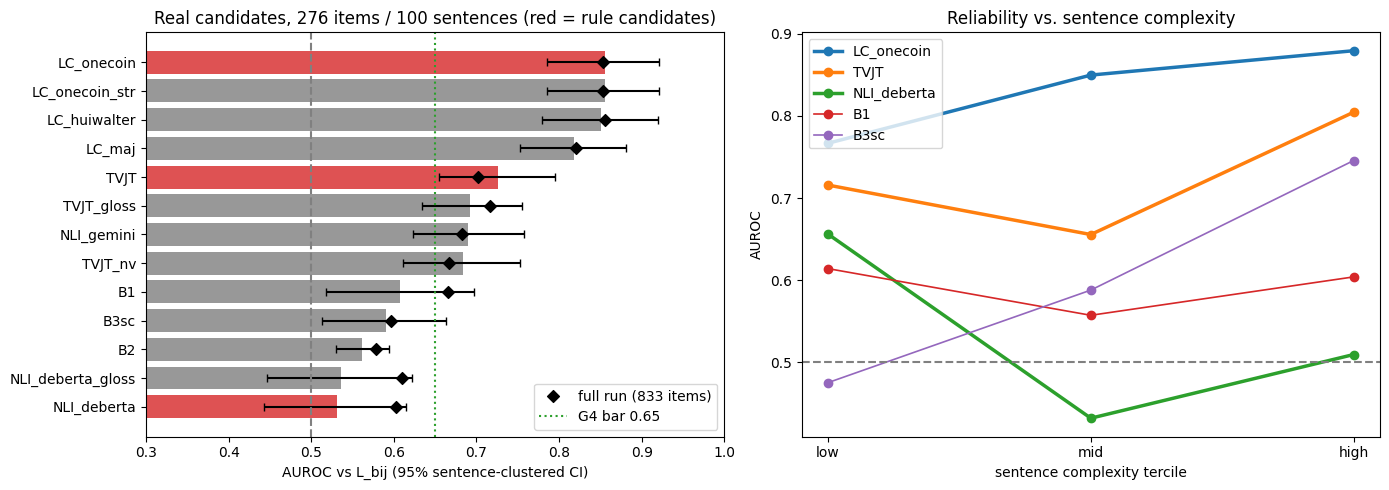

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
t2 = tab.dropna(subset=["AUROC"]).iloc[::-1]
lo = [a - c[0] for a, c in zip(t2["AUROC"], t2["CI95"])]
hi = [c[1] - a for a, c in zip(t2["AUROC"], t2["CI95"])]
colors = ["tab:red" if m in RULE else "tab:gray" for m in t2["metric"]]
axes[0].barh(t2["metric"], t2["AUROC"], xerr=[lo, hi], color=colors, alpha=0.8, capsize=3)
axes[0].scatter(t2["full_run_AUROC"], t2["metric"], marker="D", color="k", zorder=3, label="full run (833 items)")
axes[0].axvline(0.5, ls="--", c="gray"); axes[0].axvline(0.65, ls=":", c="tab:green", label="G4 bar 0.65")
axes[0].set_xlim(0.3, 1.0); axes[0].set_xlabel("AUROC vs L_bij (95% sentence-clustered CI)")
axes[0].set_title(f"Real candidates, {len(R)} items / {R['sid'].nunique()} sentences (red = rule candidates)")
axes[0].legend(loc="lower right")

show = ["LC_onecoin", "TVJT", "NLI_deberta", "B1", "B3sc"]
x = np.arange(3)
for i, m in enumerate(show):
    vals = [out["metrics"][m]["by_tercile"][str(t)]["auroc"] or np.nan for t in (0, 1, 2)]
    axes[1].plot(x, vals, marker="o", label=m, lw=2.5 if m in RULE else 1.2)
axes[1].axhline(0.5, ls="--", c="gray")
axes[1].set_xticks(x, ["low", "mid", "high"]); axes[1].set_xlabel("sentence complexity tercile")
axes[1].set_ylabel("AUROC"); axes[1].set_title("Reliability vs. sentence complexity"); axes[1].legend()
plt.tight_layout(); plt.show()